# **CIFAR-100 Project - Transer Learning & Pretrained Models**

## Overview

CIFAR-100 is a labeled subset of the "80 Million Tiny Images" dataset, collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton at the University of Toronto. It's one of the standard benchmark datasets used in computer vision for evaluating image classification models, particularly useful for testing performance on a larger number of classes compared to its sibling dataset, CIFAR-10.

## Dataset Structure

| Property | Value |
|---|---|
| **Total images** | 60,000 |
| **Training set** | 50,000 images |
| **Test set** | 10,000 images |
| **Image size** | 32 × 32 pixels |
| **Color channels** | 3 (RGB) |
| **Number of classes** | 100 |
| **Images per class** | 600 (500 train + 100 test) |
| **File size** | ~161 MB (Python pickle format) |

## Example Superclass Groupings

| Superclass | Fine Classes |
|---|---|
| Aquatic mammals | beaver, dolphin, otter, seal, whale |
| Flowers | orchid, poppy, rose, sunflower, tulip |
| Vehicles 1 | bicycle, bus, motorcycle, pickup truck, train |
| Trees | maple, oak, palm, pine, willow |
| Large carnivores | bear, leopard, lion, tiger, wolf |

## Data Format

Each image is stored as a flat array of 3,072 values (32×32×3), typically reshaped to `(32, 32, 3)` for RGB image loading.

## Key Characteristics & Challenges

- **Low resolution (32×32)** makes fine-grained distinctions harder than in higher-resolution datasets — small objects, texture details, and subtle inter-class differences (e.g. "maple" vs "oak" tree) are genuinely difficult even for humans at this resolution.
- **Only 500 training images per class** — significantly less data per class than CIFAR-10 (which has 5,000/class), making CIFAR-100 more prone to overfitting and a better test of a model's generalization ability.
- **Higher inherent difficulty** — with more classes, less data per class, and finer-grained distinctions, state-of-the-art accuracy on CIFAR-100 is typically lower than on CIFAR-10 for comparable architectures (e.g. a ResNet that gets ~95%+ on CIFAR-10 might get ~75-80% on CIFAR-100).
- **No official validation split** — most researchers carve out a validation set from the training 50,000 themselves (commonly a 45k/5k split).


# **Libraries**

In [ ]:
import os
import time
import random
import pathlib
import numpy as np
import pandas as pd
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import (
    confusion_matrix, classification_report,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical

import warnings

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


# **Data Loading**

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 100)
y_test = keras.utils.to_categorical(y_test, 100)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3), y_train shape: (50000, 100)
x_test shape: (10000, 32, 32, 3), y_test shape: (10000, 100)


# **Classes**

In [ ]:
# Source: https://www.cs.toronto.edu/~kriz/cifar.html
cifar100_fine_labels = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shrew", "skunk", "skyscraper", "snail", "snake", "spider", "squirrel",
    "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm", "zebra"
]
print(f"{len(cifar100_fine_labels)} CIFAR-100 classes")

100 CIFAR-100 classes


# **Analysis & Preprocessing**

show some samples of data

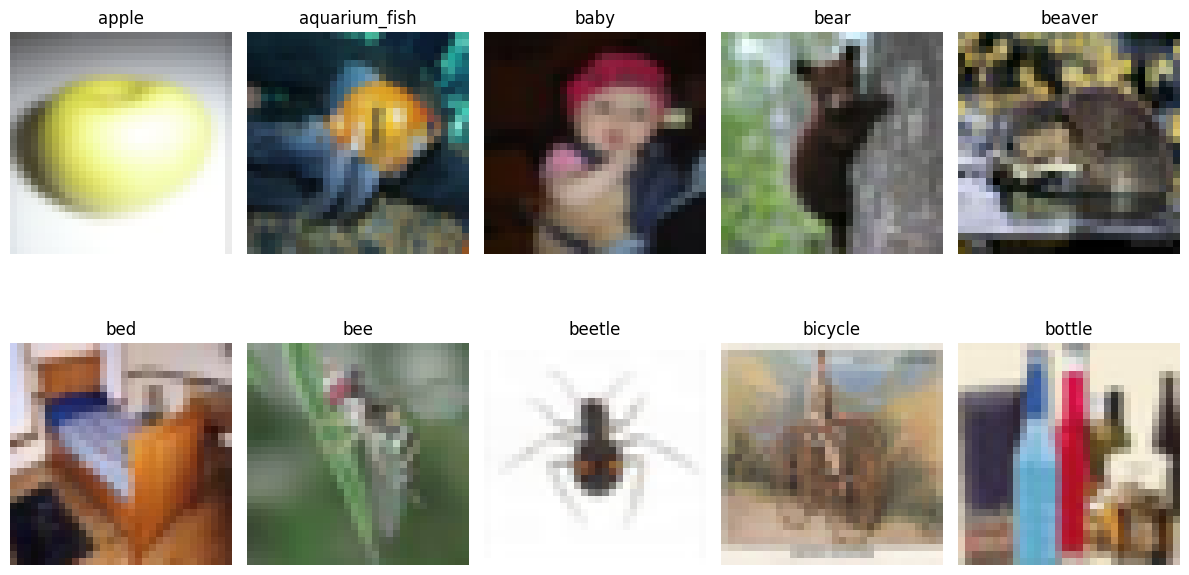

In [ ]:
y_train_class_indices = np.argmax(y_train, axis=1)

plt.figure(figsize=(12, 7))

num_to_display = 10
displayed_count = 0

for class_idx, cls_name in enumerate(cifar100_fine_labels):
    if displayed_count >= num_to_display:
        break

    matching_indices = np.where(y_train_class_indices == class_idx)[0]

    if len(matching_indices) > 0:
        img_index_in_x_train = random.choice(matching_indices)
        img_data = x_train[img_index_in_x_train]

        plt.subplot(2, 5, displayed_count + 1)
        plt.imshow(img_data)
        plt.title(cls_name)
        plt.axis("off")
        displayed_count += 1

plt.tight_layout()
plt.show()

## **Preprocessing Layers**

In [ ]:
IMG_SIZE = 128
NUM_CLASSES = 100
BATCH_SIZE = 64

preprocess_input = keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1./127.5, offset=-1) # Rescale to [-1, 1]
])

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Preprocessing layers and datasets created.


# **Data Augmentation**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# **Some Functions**

In [ ]:
def build_model(backbone_model, data_augmentation, NUM_CLASSES):
    model = tf.keras.Sequential([
        layers.Input(shape = (IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        backbone_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation = 'softmax')
    ])
    return model

In [ ]:
def train_model(model, text, train_ds, validate_ds, learning_rate = 1e-5, EPOCHS = 5):
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True),
        tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.95),
        tf.keras.callbacks.ModelCheckpoint(f"{text} best_model.h5", save_best_only = True, monitor = 'val_loss', mode = 'min')
    ]

    history_mnv2 = model.fit(
        train_ds,
        validation_data = validate_ds,
        epochs = EPOCHS,
        callbacks = callbacks
    )

    return history_mnv2

In [ ]:
def plot_loss_accuracy_comparison (history):
    loss = history.history['loss']
    loss_val = history.history['val_loss']
    accuracy = history.history['accuracy']
    accuracy_val = history.history['val_accuracy']

    plt.figure(figsize = (12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(loss, label = 'Training Loss')
    plt.plot(loss_val, label = 'Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(accuracy, label = 'Training Accuracy')
    plt.plot(accuracy_val, label = 'Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

In [ ]:
def confunsion_matrix_and_classfication_report(model, dataset, title="Confusion Matrix", class_names=None, display_confusion_for_worst_n_classes=10, plot_full_cm=False):
    y_true, y_pred, y_probs = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        labels = np.argmax(labels.numpy(), axis=1) if len(labels.shape) > 1 else labels.numpy()

        y_true.extend(labels)
        y_pred.extend(preds)
        y_probs.extend(probs)

    y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)

    all_labels = list(range(len(class_names)))

    print(f"\n{title}\n" + "-" * len(title))
    report_str = classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0)
    print(report_str)

    if plot_full_cm:

        cm_full = confusion_matrix(y_true, y_pred, labels=all_labels)
        plt.figure(figsize=(25, 25))
        sns.heatmap(cm_full, annot=False, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'{title} (All Classes - Crowded)')
        plt.tight_layout()
        plt.show()

    elif display_confusion_for_worst_n_classes > 0:

        f1_scores = f1_score(y_true, y_pred, labels=all_labels, average=None, zero_division=0)
        worst_classes_indices = np.argsort(f1_scores)[:display_confusion_for_worst_n_classes]

        filtered_y_true = []
        filtered_y_pred = []
        filtered_class_names = [class_names[i] for i in worst_classes_indices]

        for i in range(len(y_true)):
            if y_true[i] in worst_classes_indices or y_pred[i] in worst_classes_indices:
                filtered_y_true.append(y_true[i])
                filtered_y_pred.append(y_pred[i])

        old_to_new_index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(worst_classes_indices)}
        remapped_y_true = [old_to_new_index_map.get(label, -1) for label in filtered_y_true]
        remapped_y_pred = [old_to_new_index_map.get(label, -1) for label in filtered_y_pred]

        final_remapped_y_true = [t for t in remapped_y_true if t != -1]
        final_remapped_y_pred = [p for i, p in enumerate(remapped_y_pred) if remapped_y_true[i] != -1]

        if not final_remapped_y_true:
            print(f"No examples found for the worst {display_confusion_for_worst_n_classes} classes to display a confusion matrix.")
        else:
            cm_filtered = confusion_matrix(final_remapped_y_true, final_remapped_y_pred, labels=list(range(len(filtered_class_names))))

            plt.figure(figsize=(display_confusion_for_worst_n_classes * 1.2, display_confusion_for_worst_n_classes * 1.2))
            sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues',
                        xticklabels=filtered_class_names, yticklabels=filtered_class_names)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(f'{title} (Worst {display_confusion_for_worst_n_classes} Classes by F1-Score)')
            plt.tight_layout()
            plt.show()

    return y_true, y_pred, y_probs

In [ ]:
def show_misclassified_examples_standalone(model, x_test_raw, y_test_raw, class_names, n=9):
    probs = model.predict(x_test_raw, verbose=0)
    y_pred_indices = np.argmax(probs, axis=1)

    if len(y_test_raw.shape) > 1 and y_test_raw.shape[1] > 1:
        y_true_indices = np.argmax(y_test_raw, axis=1)
    else:
        y_true_indices = y_test_raw

    mismatches = [i for i, (t, p) in enumerate(zip(y_true_indices, y_pred_indices)) if t != p]
    display_mismatches = mismatches[:n]

    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(display_mismatches):
        plt.subplot(3, 3, i + 1)
        plt.imshow(x_test_raw[idx])
        plt.title(f"True: {class_names[y_true_indices[idx]]}\nPred: {class_names[y_pred_indices[idx]]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# **Main Task : Fine-Tuning & Model Training & Comparison**

## **Phase 1: Feature Extraction**

### **Model A: ResNet50V2 with Frozen Backbone**

In [ ]:
base_model_resnet = keras.applications.ResNet50V2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model_resnet.trainable = False

model_resnet = build_model(base_model_resnet, data_augmentation, NUM_CLASSES)

model_resnet.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 204,900 (800.39 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
start_time_resnet = time.time()
history_resnet = train_model(model_resnet, "ResNet50V2", train_dataset, test_dataset)
end_time_resnet = time.time()
training_time_resnet = end_time_resnet - start_time_resnet

print(f"\nResNet50V2 Training Time: {training_time_resnet:.2f} seconds")
print(f"ResNet50V2 Validation Accuracy: {history_resnet.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.0096 - loss: 4.9580

782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 115ms/step - accuracy: 0.0098 - loss: 4.9208 - val_accuracy: 0.0095 - val_loss: 4.7860 - learning_rate: 9.5000e-06
Epoch 2/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0093 - loss: 4.8231

782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.0090 - loss: 4.8010 - val_accuracy: 0.0094 - val_loss: 4.7045 - learning_rate: 9.0250e-06
Epoch 3/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.0112 - loss: 4.7416

782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.0099 - loss: 4.7314 - val_accuracy: 0.0105 - val_loss: 4.6582 - learning_rate: 8.5737e-06
Epoch 4/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0106 - loss: 4.6974

782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.0104 - loss: 4.6916 - val_accuracy: 0.0106 - val_loss: 4.6313 - learning_rate: 8.1451e-06
Epoch 5/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0105 - loss: 4.6736

782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.0106 - loss: 4.6687 - val_accuracy: 0.0117 - val_loss: 4.6152 - learning_rate: 7.7378e-06

ResNet50V2 Training Time: 414.39 seconds
ResNet50V2 Validation Accuracy: 0.0117


#### **Results of ResNet50**

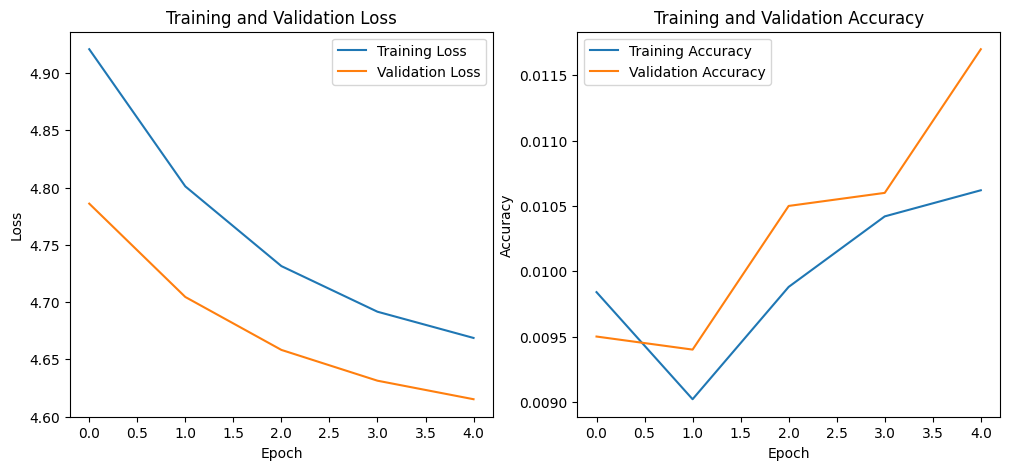

In [ ]:
plot_loss_accuracy_comparison(history_resnet)

Displaying Confusion Matrix for worst 30 classes & classification report


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00       100
aquarium_fish       0.00      0.00      0.00       100
         baby       0.00      0.00      0.00       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.00      0.00      0.00       100
          bee       0.00      0.00      0.00       100
       beetle       0.00      0.00      0.00       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.00      0.00      0.00       100
         bowl       0.00      0.00      0.00       100
          boy       0.00      0.00      0.00       100
       bridge       0.00      0.00      0.00       100
          bus       0.00      0.00      0.00       100
    butterfly       0.04      0.01      0.02       100
        camel       0.00      0.00      0.00       100
   

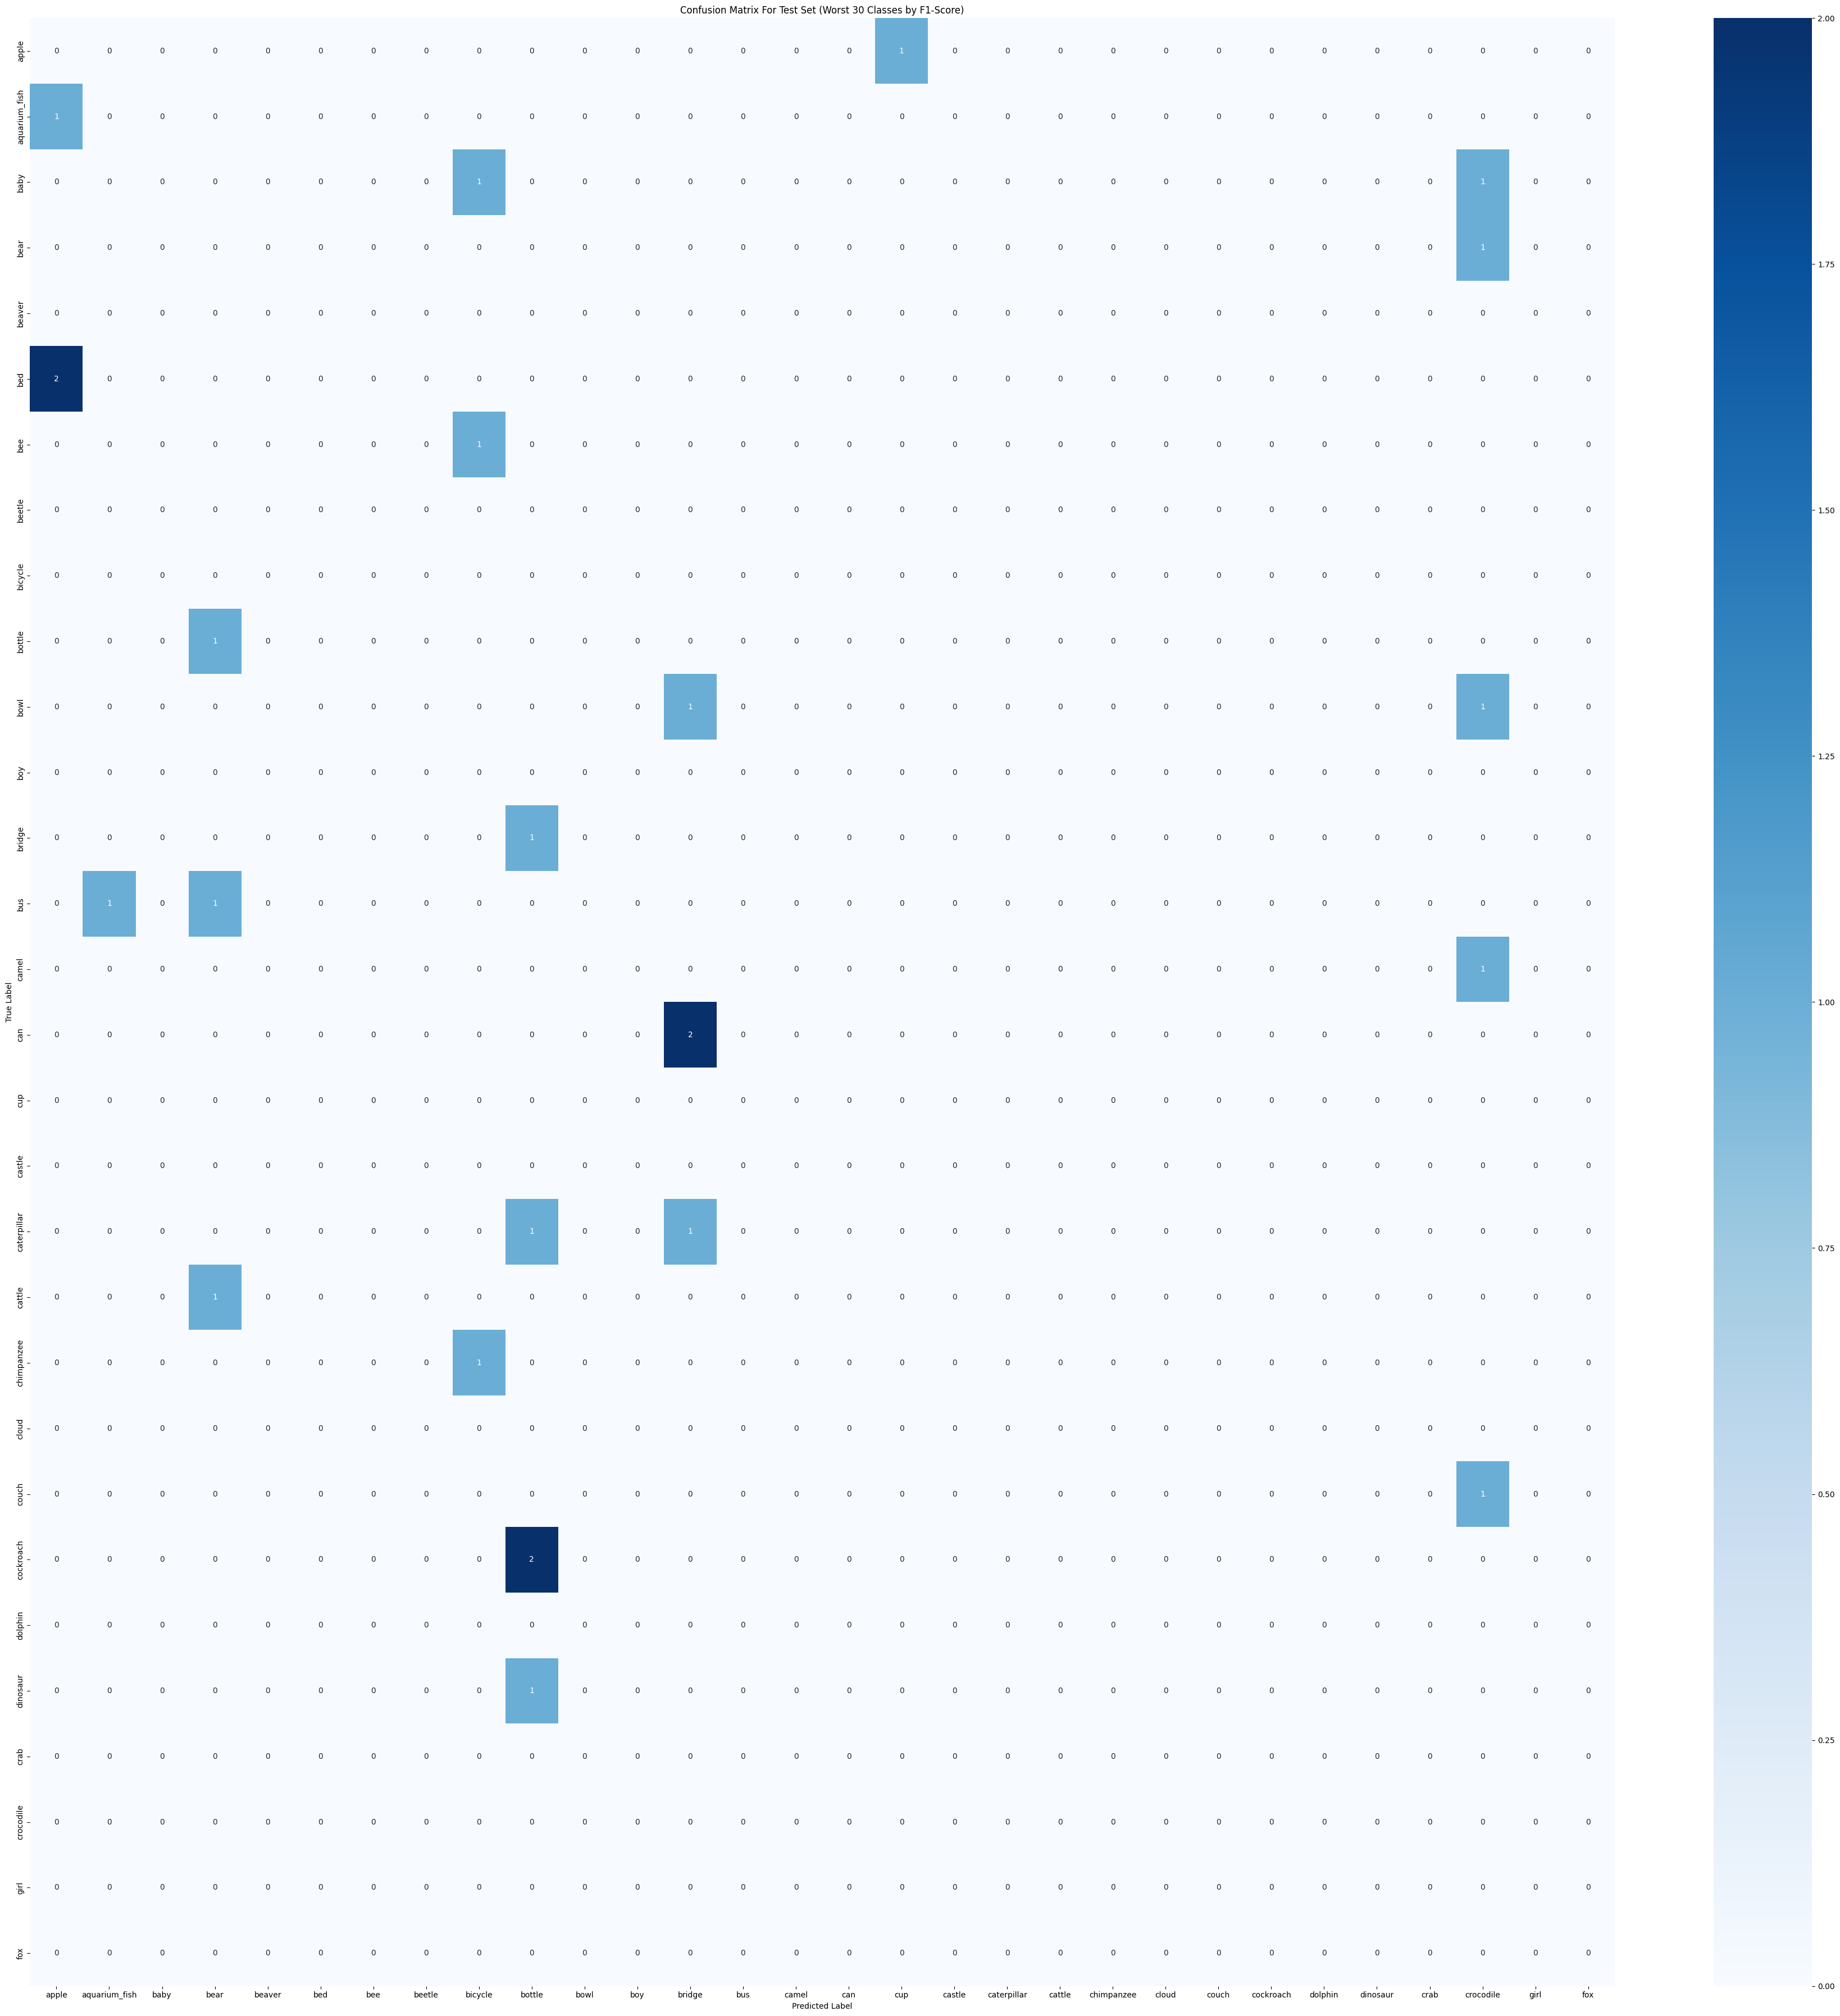

(array([49, 33, 72, ..., 51, 42, 70]),
 array([78, 31, 41, ..., 41, 78, 31]),
 array([[0.01266703, 0.0118868 , 0.00777995, ..., 0.00739784, 0.01134911,
         0.01022344],
        [0.01313053, 0.01065649, 0.00725074, ..., 0.00824476, 0.01157503,
         0.01134092],
        [0.01259692, 0.01164852, 0.0072213 , ..., 0.00860562, 0.01147312,
         0.01064489],
        ...,
        [0.01229881, 0.01193145, 0.00765071, ..., 0.00798308, 0.0117787 ,
         0.0102405 ],
        [0.01336173, 0.01050314, 0.00742106, ..., 0.00895273, 0.01112239,
         0.01139597],
        [0.01234756, 0.01030244, 0.00719709, ..., 0.00950476, 0.01160603,
         0.01122411]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_resnet, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

Displaying Misclassified Examples

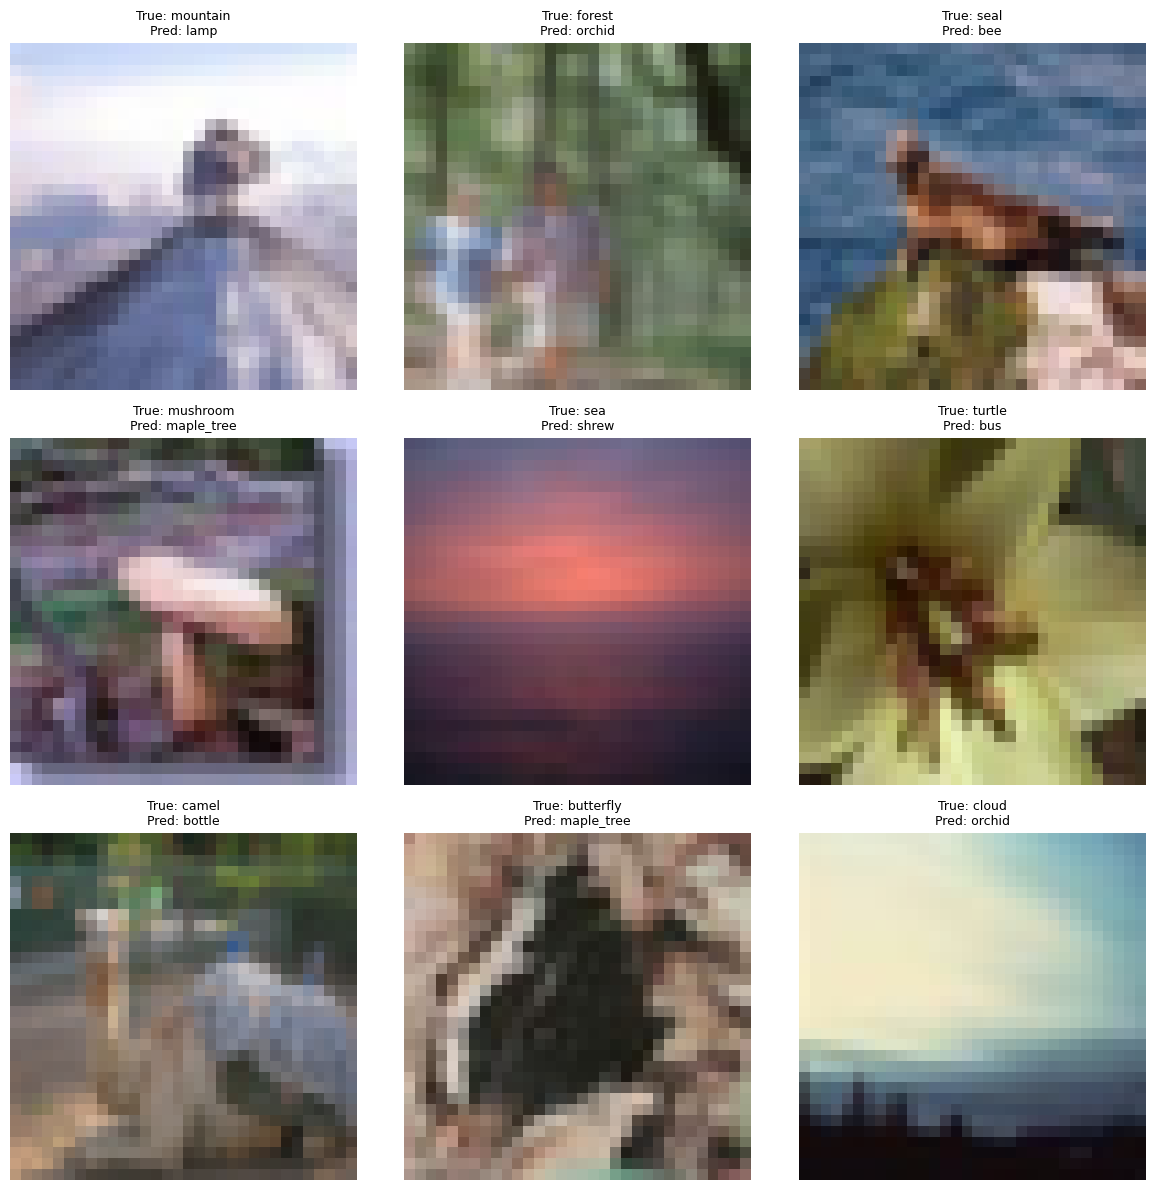

In [ ]:
show_misclassified_examples_standalone(model_resnet, x_test, y_test, cifar100_fine_labels)

In [ ]:
results = {
    'ResNet50V2': {
        'training_time': training_time_resnet,
        'val_accuracy': history_resnet.history['val_accuracy'][-1],
        'history': history_resnet
    }
}

### **Model B: MobileNetV2 with Frozen Backbone**

In [ ]:
base_model_mobilenet = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model_mobilenet.trainable = False

model_mobilenet = build_model(base_model_mobilenet, data_augmentation, NUM_CLASSES)

model_mobilenet.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 128,100 (500.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
start_time_mobilenet = time.time()
history_mobilenet = train_model(model_mobilenet, "MobileNetV2", train_dataset, test_dataset)
end_time_mobilenet = time.time()
training_time_mobilenet = end_time_mobilenet - start_time_mobilenet

print(f"\nMobileNetV2 Training Time: {training_time_mobilenet:.2f} seconds")
print(f"MobileNetV2 Validation Accuracy: {history_mobilenet.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0100 - loss: 5.1183

782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 51ms/step - accuracy: 0.0107 - loss: 4.9742 - val_accuracy: 0.0100 - val_loss: 4.6662 - learning_rate: 9.5000e-06
Epoch 2/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0110 - loss: 4.7769

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.0103 - loss: 4.7597 - val_accuracy: 0.0107 - val_loss: 4.6114 - learning_rate: 9.0250e-06
Epoch 3/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0092 - loss: 4.7358

782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.0094 - loss: 4.7383 - val_accuracy: 0.0137 - val_loss: 4.6069 - learning_rate: 8.5737e-06
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0094 - loss: 4.7354

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.0099 - loss: 4.7354 - val_accuracy: 0.0110 - val_loss: 4.6062 - learning_rate: 8.1451e-06
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0099 - loss: 4.7318

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.0097 - loss: 4.7314 - val_accuracy: 0.0111 - val_loss: 4.6058 - learning_rate: 7.7378e-06

MobileNetV2 Training Time: 199.23 seconds
MobileNetV2 Validation Accuracy: 0.0111


#### **Results of MobileNetV2**

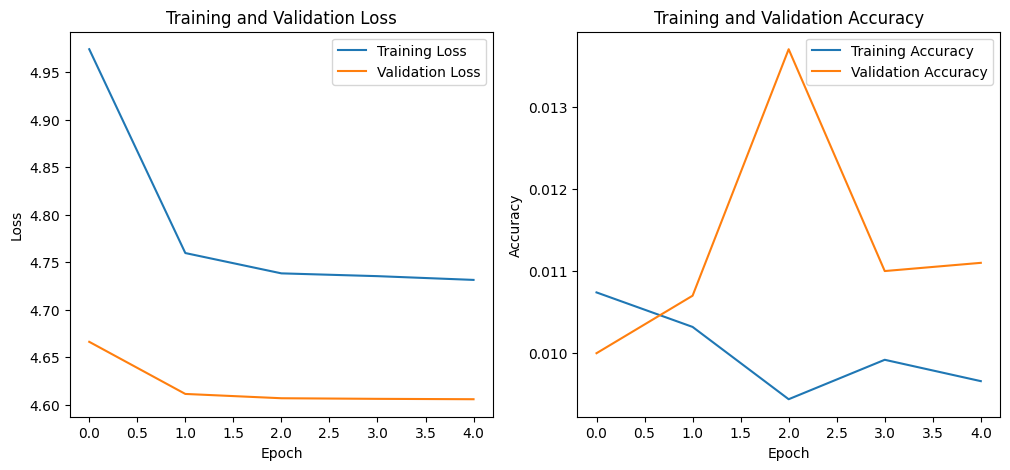

In [ ]:
plot_loss_accuracy_comparison(history_mobilenet)


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00       100
aquarium_fish       0.00      0.00      0.00       100
         baby       0.02      0.06      0.03       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.00      0.00      0.00       100
          bee       0.01      0.14      0.01       100
       beetle       0.00      0.00      0.00       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.00      0.00      0.00       100
         bowl       0.00      0.00      0.00       100
          boy       0.05      0.01      0.02       100
       bridge       0.00      0.00      0.00       100
          bus       0.01      0.01      0.01       100
    butterfly       0.00      0.00      0.00       100
        camel       0.00      0.01      0.00       100
   

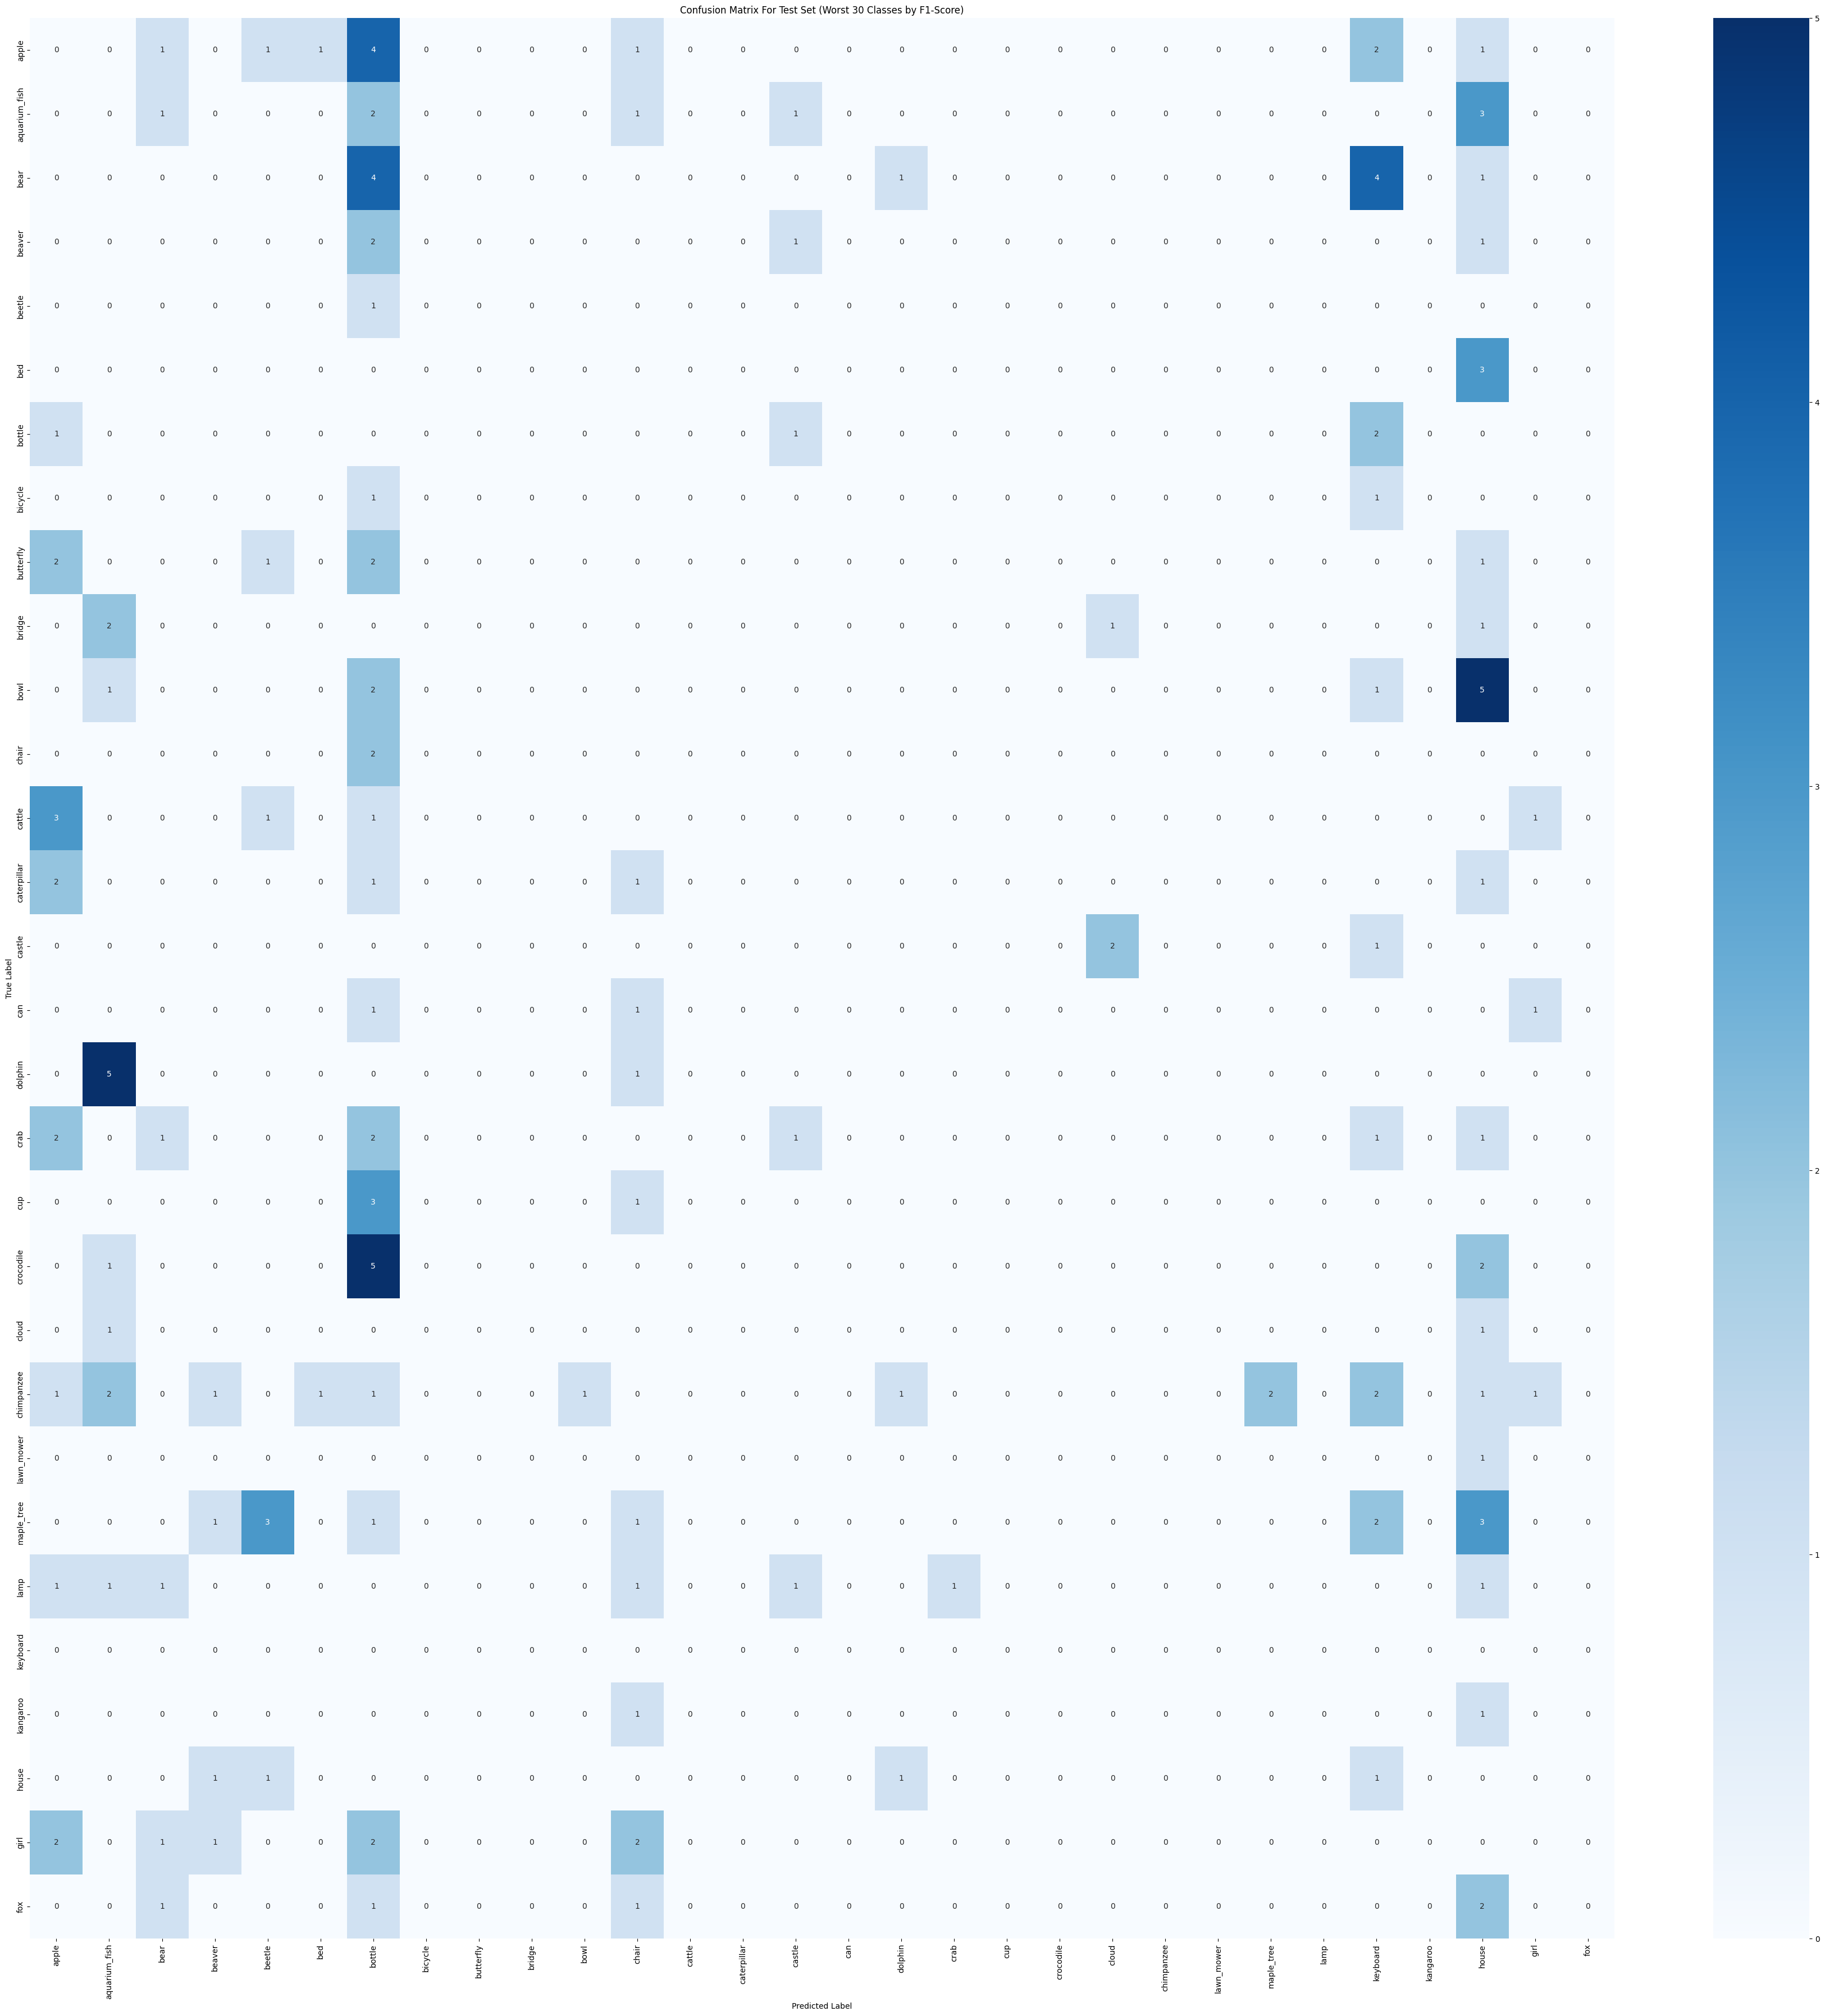

(array([49, 33, 72, ..., 51, 42, 70]),
 array([74, 86, 29, ..., 74, 86, 45]),
 array([[0.01013444, 0.01029585, 0.01003191, ..., 0.01017558, 0.01008879,
         0.0099459 ],
        [0.01016065, 0.01012644, 0.01038133, ..., 0.01045696, 0.00980979,
         0.00984491],
        [0.01020071, 0.01017631, 0.01016789, ..., 0.01024194, 0.01027705,
         0.01014478],
        ...,
        [0.0103586 , 0.01021484, 0.01029656, ..., 0.01021009, 0.00993675,
         0.010057  ],
        [0.0104241 , 0.0098851 , 0.01066373, ..., 0.0103392 , 0.0098388 ,
         0.01002227],
        [0.01034555, 0.00989656, 0.0104278 , ..., 0.0102301 , 0.01045259,
         0.00989285]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_mobilenet, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [ ]:
results['MobileNetV2'] = {
    'training_time': training_time_mobilenet,
    'val_accuracy': history_mobilenet.history['val_accuracy'][-1],
    'history': history_mobilenet
}

### **Comparison of Models (ResNet50V2 vs. MobileNetV2)**

In [ ]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 414.39 seconds
  Validation Accuracy: 0.0117
  Effiency -> Accuracy / Seconds : 2.8234016106300675e-05
Model: MobileNetV2
  Training Time: 199.23 seconds
  Validation Accuracy: 0.0111
  Effiency -> Accuracy / Seconds : 5.571361899399804e-05

Best by Accuracy: ResNet50V2 (0.0117)
Best by Time: MobileNetV2 (199.2331)
Efficient (accuracy/sec): MobileNetV2 (0.000056)


Best Model by Accuracy: ResNet50V2

ResNet50V2 has higher accuracy, but MobileNetV2 trains faster.

Most Efficient Model (accuracy/sec): MobileNetV2

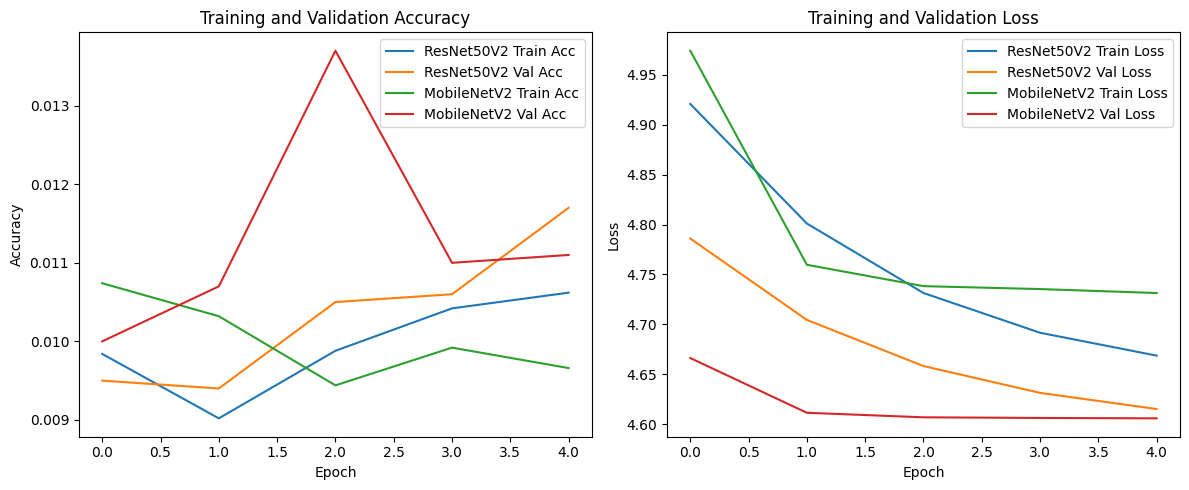

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results['ResNet50V2']['history'].history['accuracy'], label='ResNet50V2 Train Acc')
plt.plot(results['ResNet50V2']['history'].history['val_accuracy'], label='ResNet50V2 Val Acc')
plt.plot(results['MobileNetV2']['history'].history['accuracy'], label='MobileNetV2 Train Acc')
plt.plot(results['MobileNetV2']['history'].history['val_accuracy'], label='MobileNetV2 Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['ResNet50V2']['history'].history['loss'], label='ResNet50V2 Train Loss')
plt.plot(results['ResNet50V2']['history'].history['val_loss'], label='ResNet50V2 Val Loss')
plt.plot(results['MobileNetV2']['history'].history['loss'], label='MobileNetV2 Train Loss')
plt.plot(results['MobileNetV2']['history'].history['val_loss'], label='MobileNetV2 Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## **Phase 2: The Winner's Circle (Percentage-Based Unfreezing)**

### **Strategy A: Top 10% Unfreezing for MobileNetV2**

In [ ]:
base_model_mobilenet_unfreeze_10 = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
model_mobilenet_10 = build_model(base_model_mobilenet_unfreeze_10, data_augmentation, NUM_CLASSES)

In [ ]:
base_model_mobilenet_unfreeze_10.trainable = True

In [ ]:
total_layers_mobile_net = len(base_model_mobilenet.layers)
unfreeze_percentage_10 = 0.10
freeze_until_10 = int(total_layers_mobile_net * (1.0 - unfreeze_percentage_10))

for layer in base_model_mobilenet_unfreeze_10.layers[:freeze_until_10]:
    layer.trainable = False

In [ ]:
model_mobilenet_10.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 1,170,020 (4.46 MB)

 Non-trainable params: 1,216,064 (4.64 MB)

In [ ]:
start_time_mobilenet_unfreeze_10 = time.time()
history_mobilenet_unfreeze_10 = train_model(model_mobilenet_10, "MobileNetV2_Unfreeze_10", train_dataset, test_dataset)
end_time_mobilenet_unfreeze_10 = time.time()
training_time_mobilenet_unfreeze_10 = end_time_mobilenet_unfreeze_10 - start_time_mobilenet_unfreeze_10

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0217 - loss: 4.6010

782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.0351 - loss: 4.5029 - val_accuracy: 0.0103 - val_loss: 4.8833 - learning_rate: 9.5000e-06
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.0674 - loss: 4.2719 - val_accuracy: 0.0108 - val_loss: 4.9689 - learning_rate: 9.0250e-06
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.0818 - loss: 4.1434 - val_accuracy: 0.0100 - val_loss: 5.2010 - learning_rate: 8.5737e-06
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.0929 - loss: 4.0552 - val_accuracy: 0.0100 - val_loss: 5.3782 - learning_rate: 8.1451e-06


#### **Results**

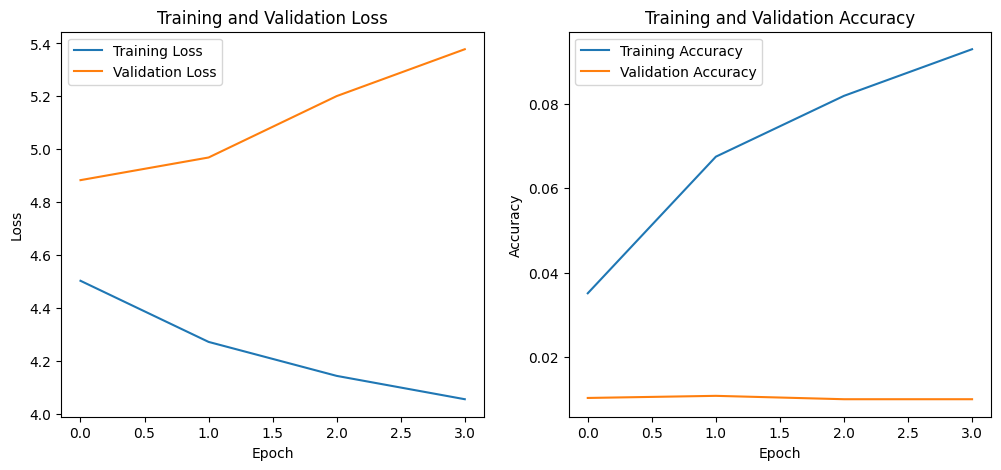

In [ ]:
plot_loss_accuracy_comparison(history_mobilenet_unfreeze_10)


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00       100
aquarium_fish       0.00      0.00      0.00       100
         baby       0.00      0.00      0.00       100
         bear       0.01      1.00      0.02       100
       beaver       0.00      0.00      0.00       100
          bed       0.00      0.00      0.00       100
          bee       0.00      0.00      0.00       100
       beetle       0.00      0.00      0.00       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.00      0.00      0.00       100
         bowl       0.00      0.00      0.00       100
          boy       0.00      0.00      0.00       100
       bridge       0.00      0.00      0.00       100
          bus       0.00      0.00      0.00       100
    butterfly       0.00      0.00      0.00       100
        camel       0.00      0.00      0.00       100
   

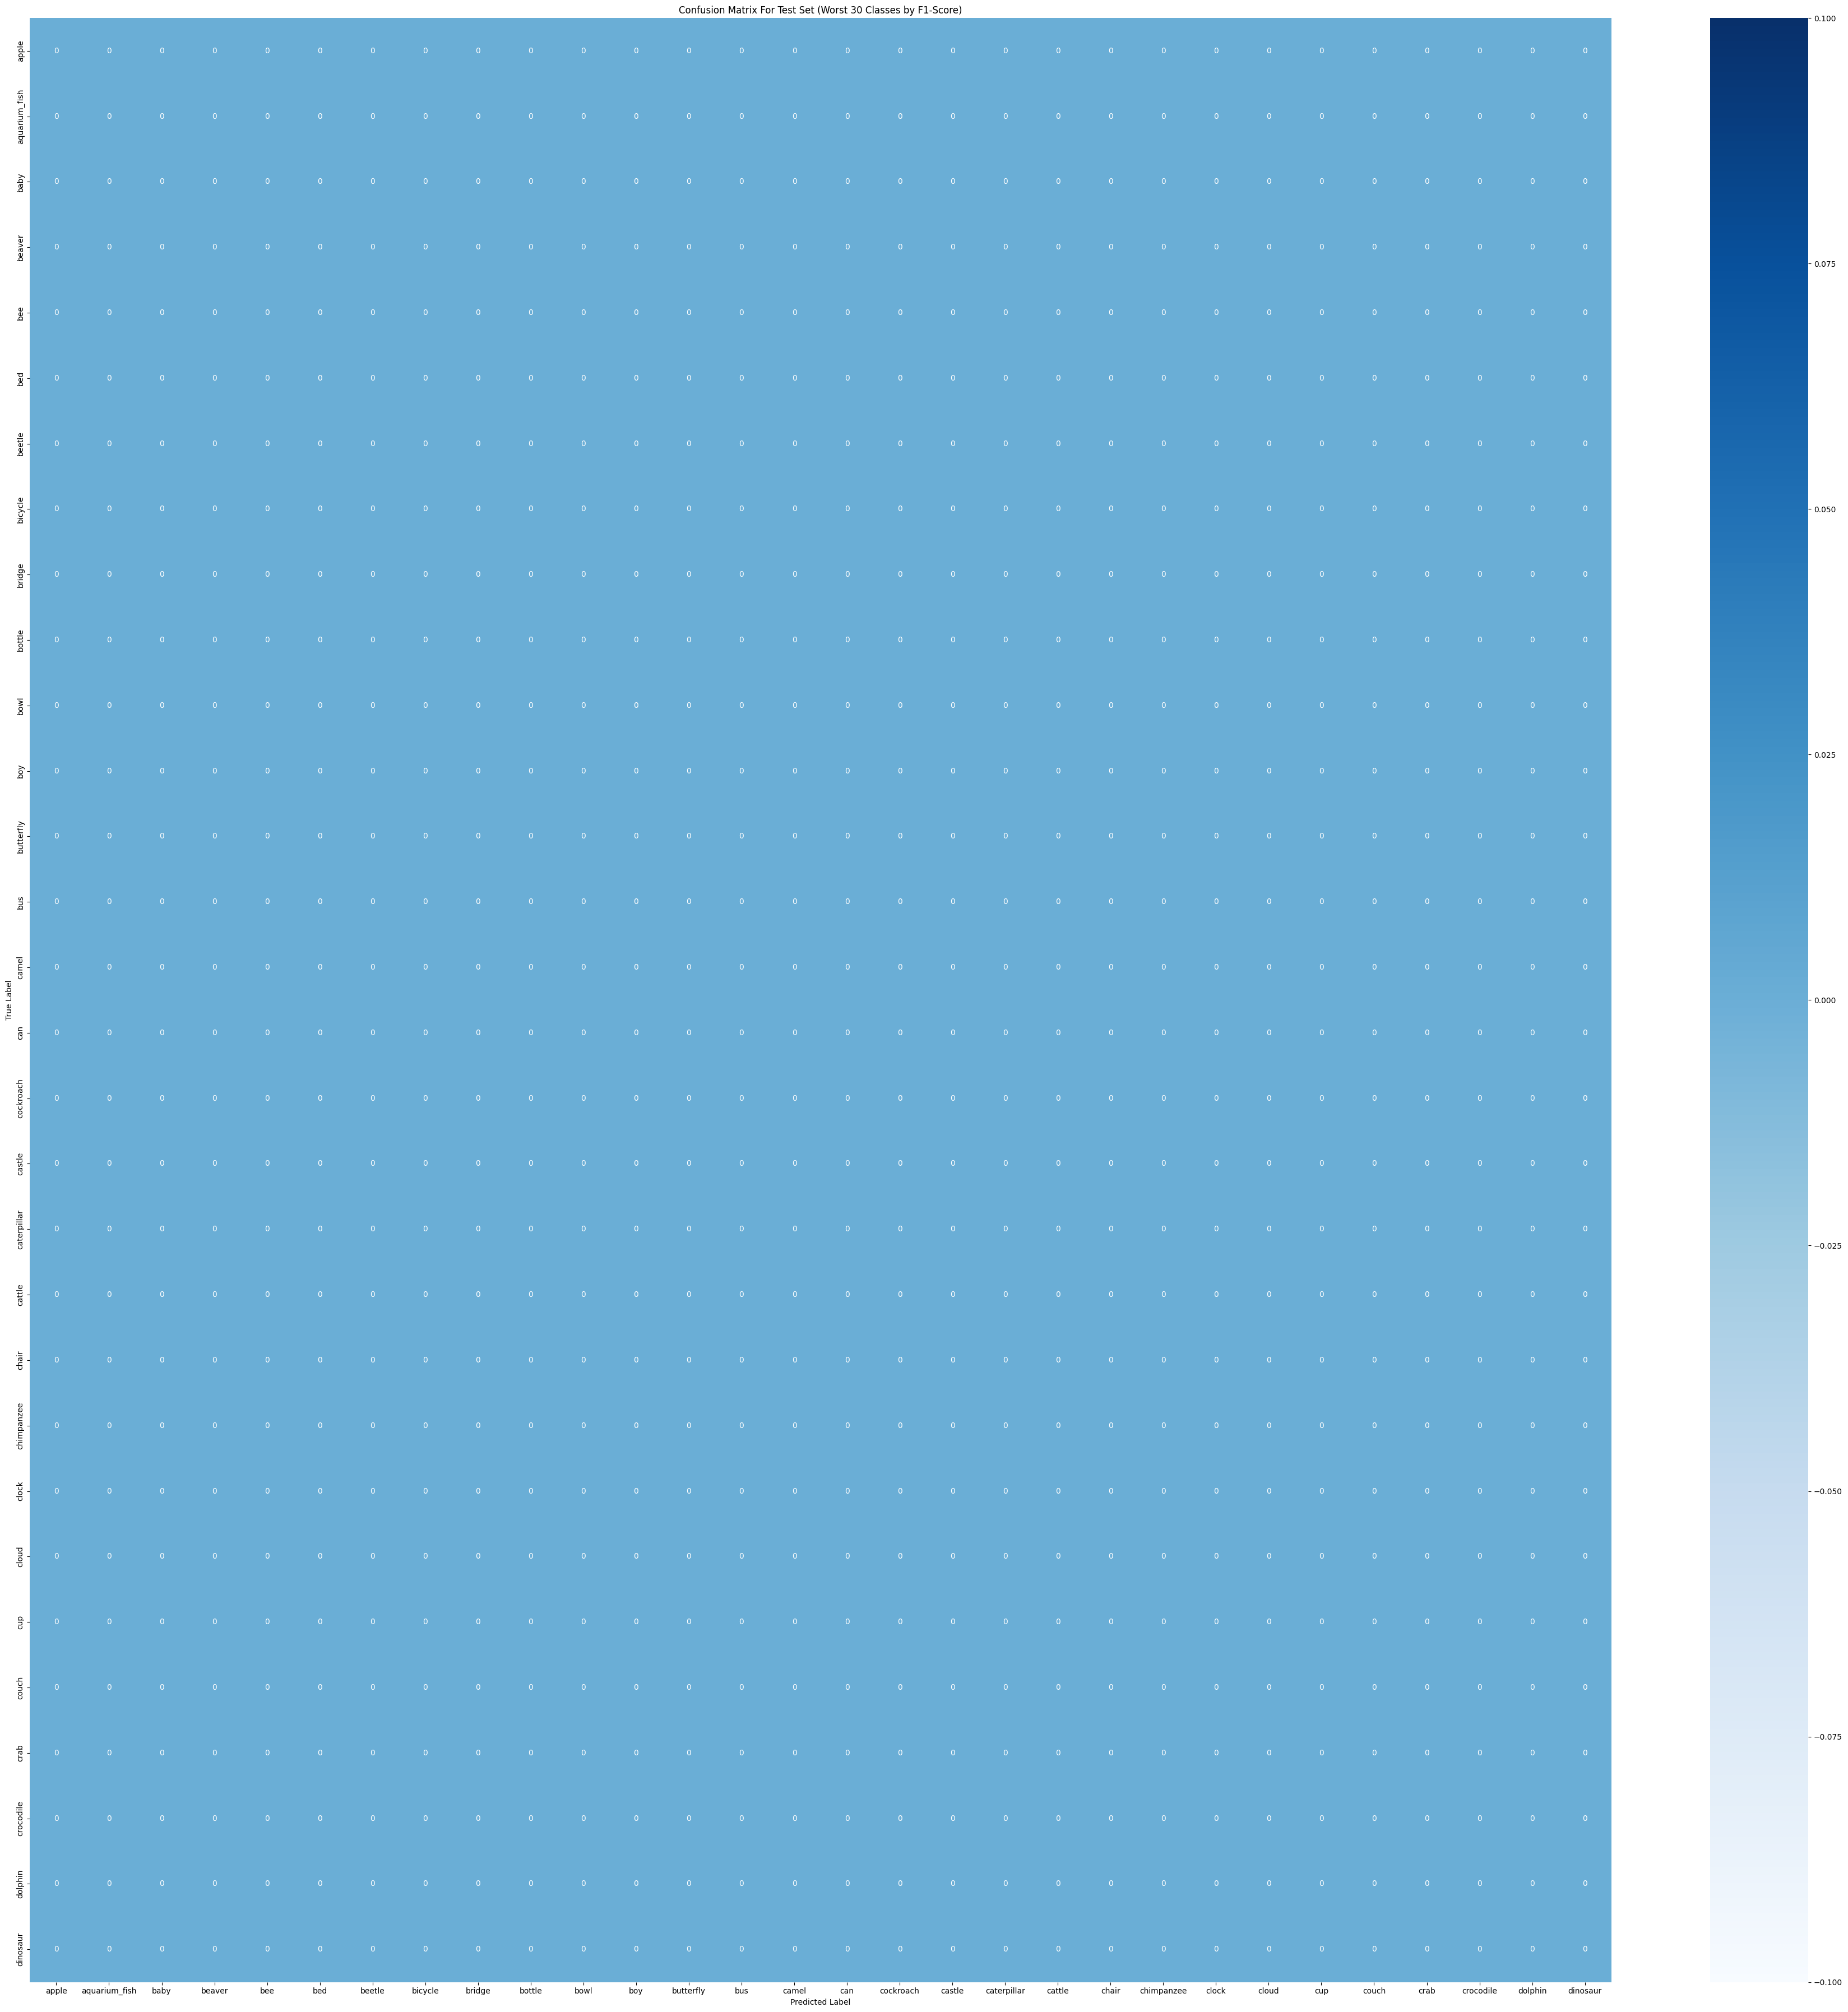

(array([49, 33, 72, ..., 51, 42, 70]),
 array([3, 3, 3, ..., 3, 3, 3]),
 array([[0.01317155, 0.00466022, 0.02276578, ..., 0.01428916, 0.01003659,
         0.03703707],
        [0.01235064, 0.00491648, 0.02283716, ..., 0.01436279, 0.00994432,
         0.0373527 ],
        [0.01314018, 0.00480355, 0.02342113, ..., 0.01436855, 0.0100976 ,
         0.03538309],
        ...,
        [0.01273554, 0.0050591 , 0.02265858, ..., 0.01418145, 0.01033738,
         0.03491208],
        [0.01280684, 0.00495138, 0.02280036, ..., 0.01471232, 0.01032836,
         0.0367668 ],
        [0.01303487, 0.00538675, 0.02218661, ..., 0.01458702, 0.01038477,
         0.03513051]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_mobilenet_10, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [ ]:
results['MobileNetV2_Unfreeze_10%'] = {
    'training_time': training_time_mobilenet_unfreeze_10,
    'val_accuracy': history_mobilenet_unfreeze_10.history['val_accuracy'][-1],
    'history': history_mobilenet_unfreeze_10
}

print(f"\MobileNetV2 Top 10% Unfreeze Training Time: {training_time_mobilenet_unfreeze_10:.2f} seconds")
print(f"MobileNetV2 Top 10% Unfreeze Validation Accuracy: {history_mobilenet_unfreeze_10.history['val_accuracy'][-1]:.4f}")

\MobileNetV2 Top 10% Unfreeze Training Time: 215.28 seconds
MobileNetV2 Top 10% Unfreeze Validation Accuracy: 0.0100


<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_4378/2610336047.py:7: SyntaxWarning: invalid escape sequence '\M'
  print(f"\MobileNetV2 Top 10% Unfreeze Training Time: {training_time_mobilenet_unfreeze_10:.2f} seconds")


### **Strategy B: Deep 35% Unfreezing for MobileNetV2**

In [ ]:
base_model_mobilenet_unfreeze_35 = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
model_mobilenet_35 = build_model(base_model_mobilenet_unfreeze_35, data_augmentation, NUM_CLASSES)

In [ ]:
base_model_mobilenet_unfreeze_35.trainable = True

In [ ]:
total_layers_mobile_net = len(base_model_mobilenet_unfreeze_35.layers)
unfreeze_percentage_35 = 0.10
freeze_until_35 = int(total_layers_mobile_net * (1.0 - unfreeze_percentage_35))

for layer in base_model_mobilenet_unfreeze_35.layers[:freeze_until_35]:
    layer.trainable = False

In [ ]:
model_mobilenet_35.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 1,170,020 (4.46 MB)

 Non-trainable params: 1,216,064 (4.64 MB)

In [ ]:
start_time_mobilenet_unfreeze_35 = time.time()
history_mobilenet_unfreeze_35 = train_model(model_mobilenet_35, "MobileNetV2_Unfreeze_35", train_dataset, test_dataset)
end_time_mobilenet_unfreeze_35 = time.time()
training_time_mobilenet_unfreeze_35 = end_time_mobilenet_unfreeze_35 - start_time_mobilenet_unfreeze_35

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0213 - loss: 4.6107

782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.0321 - loss: 4.5174 - val_accuracy: 0.0101 - val_loss: 4.8888 - learning_rate: 9.5000e-06
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.0618 - loss: 4.2948 - val_accuracy: 0.0100 - val_loss: 4.9281 - learning_rate: 9.0250e-06
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.0788 - loss: 4.1640 - val_accuracy: 0.0099 - val_loss: 5.1736 - learning_rate: 8.5737e-06
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.0883 - loss: 4.0766 - val_accuracy: 0.0100 - val_loss: 5.5927 - learning_rate: 8.1451e-06


#### **Results**

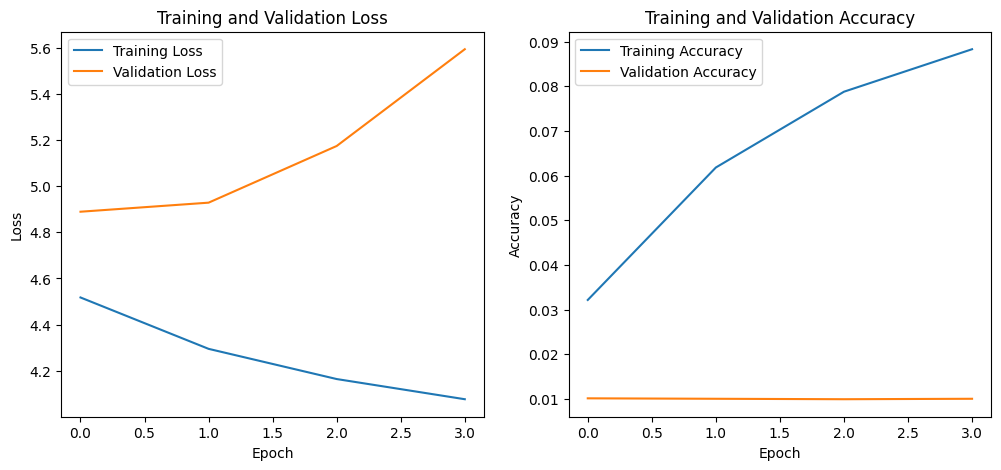

In [ ]:
plot_loss_accuracy_comparison(history_mobilenet_unfreeze_35)


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00       100
aquarium_fish       0.00      0.00      0.00       100
         baby       0.00      0.00      0.00       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.00      0.00      0.00       100
          bee       0.00      0.00      0.00       100
       beetle       0.00      0.00      0.00       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.00      0.00      0.00       100
         bowl       0.00      0.00      0.00       100
          boy       0.00      0.00      0.00       100
       bridge       0.00      0.00      0.00       100
          bus       0.00      0.00      0.00       100
    butterfly       0.00      0.00      0.00       100
        camel       0.00      0.00      0.00       100
   

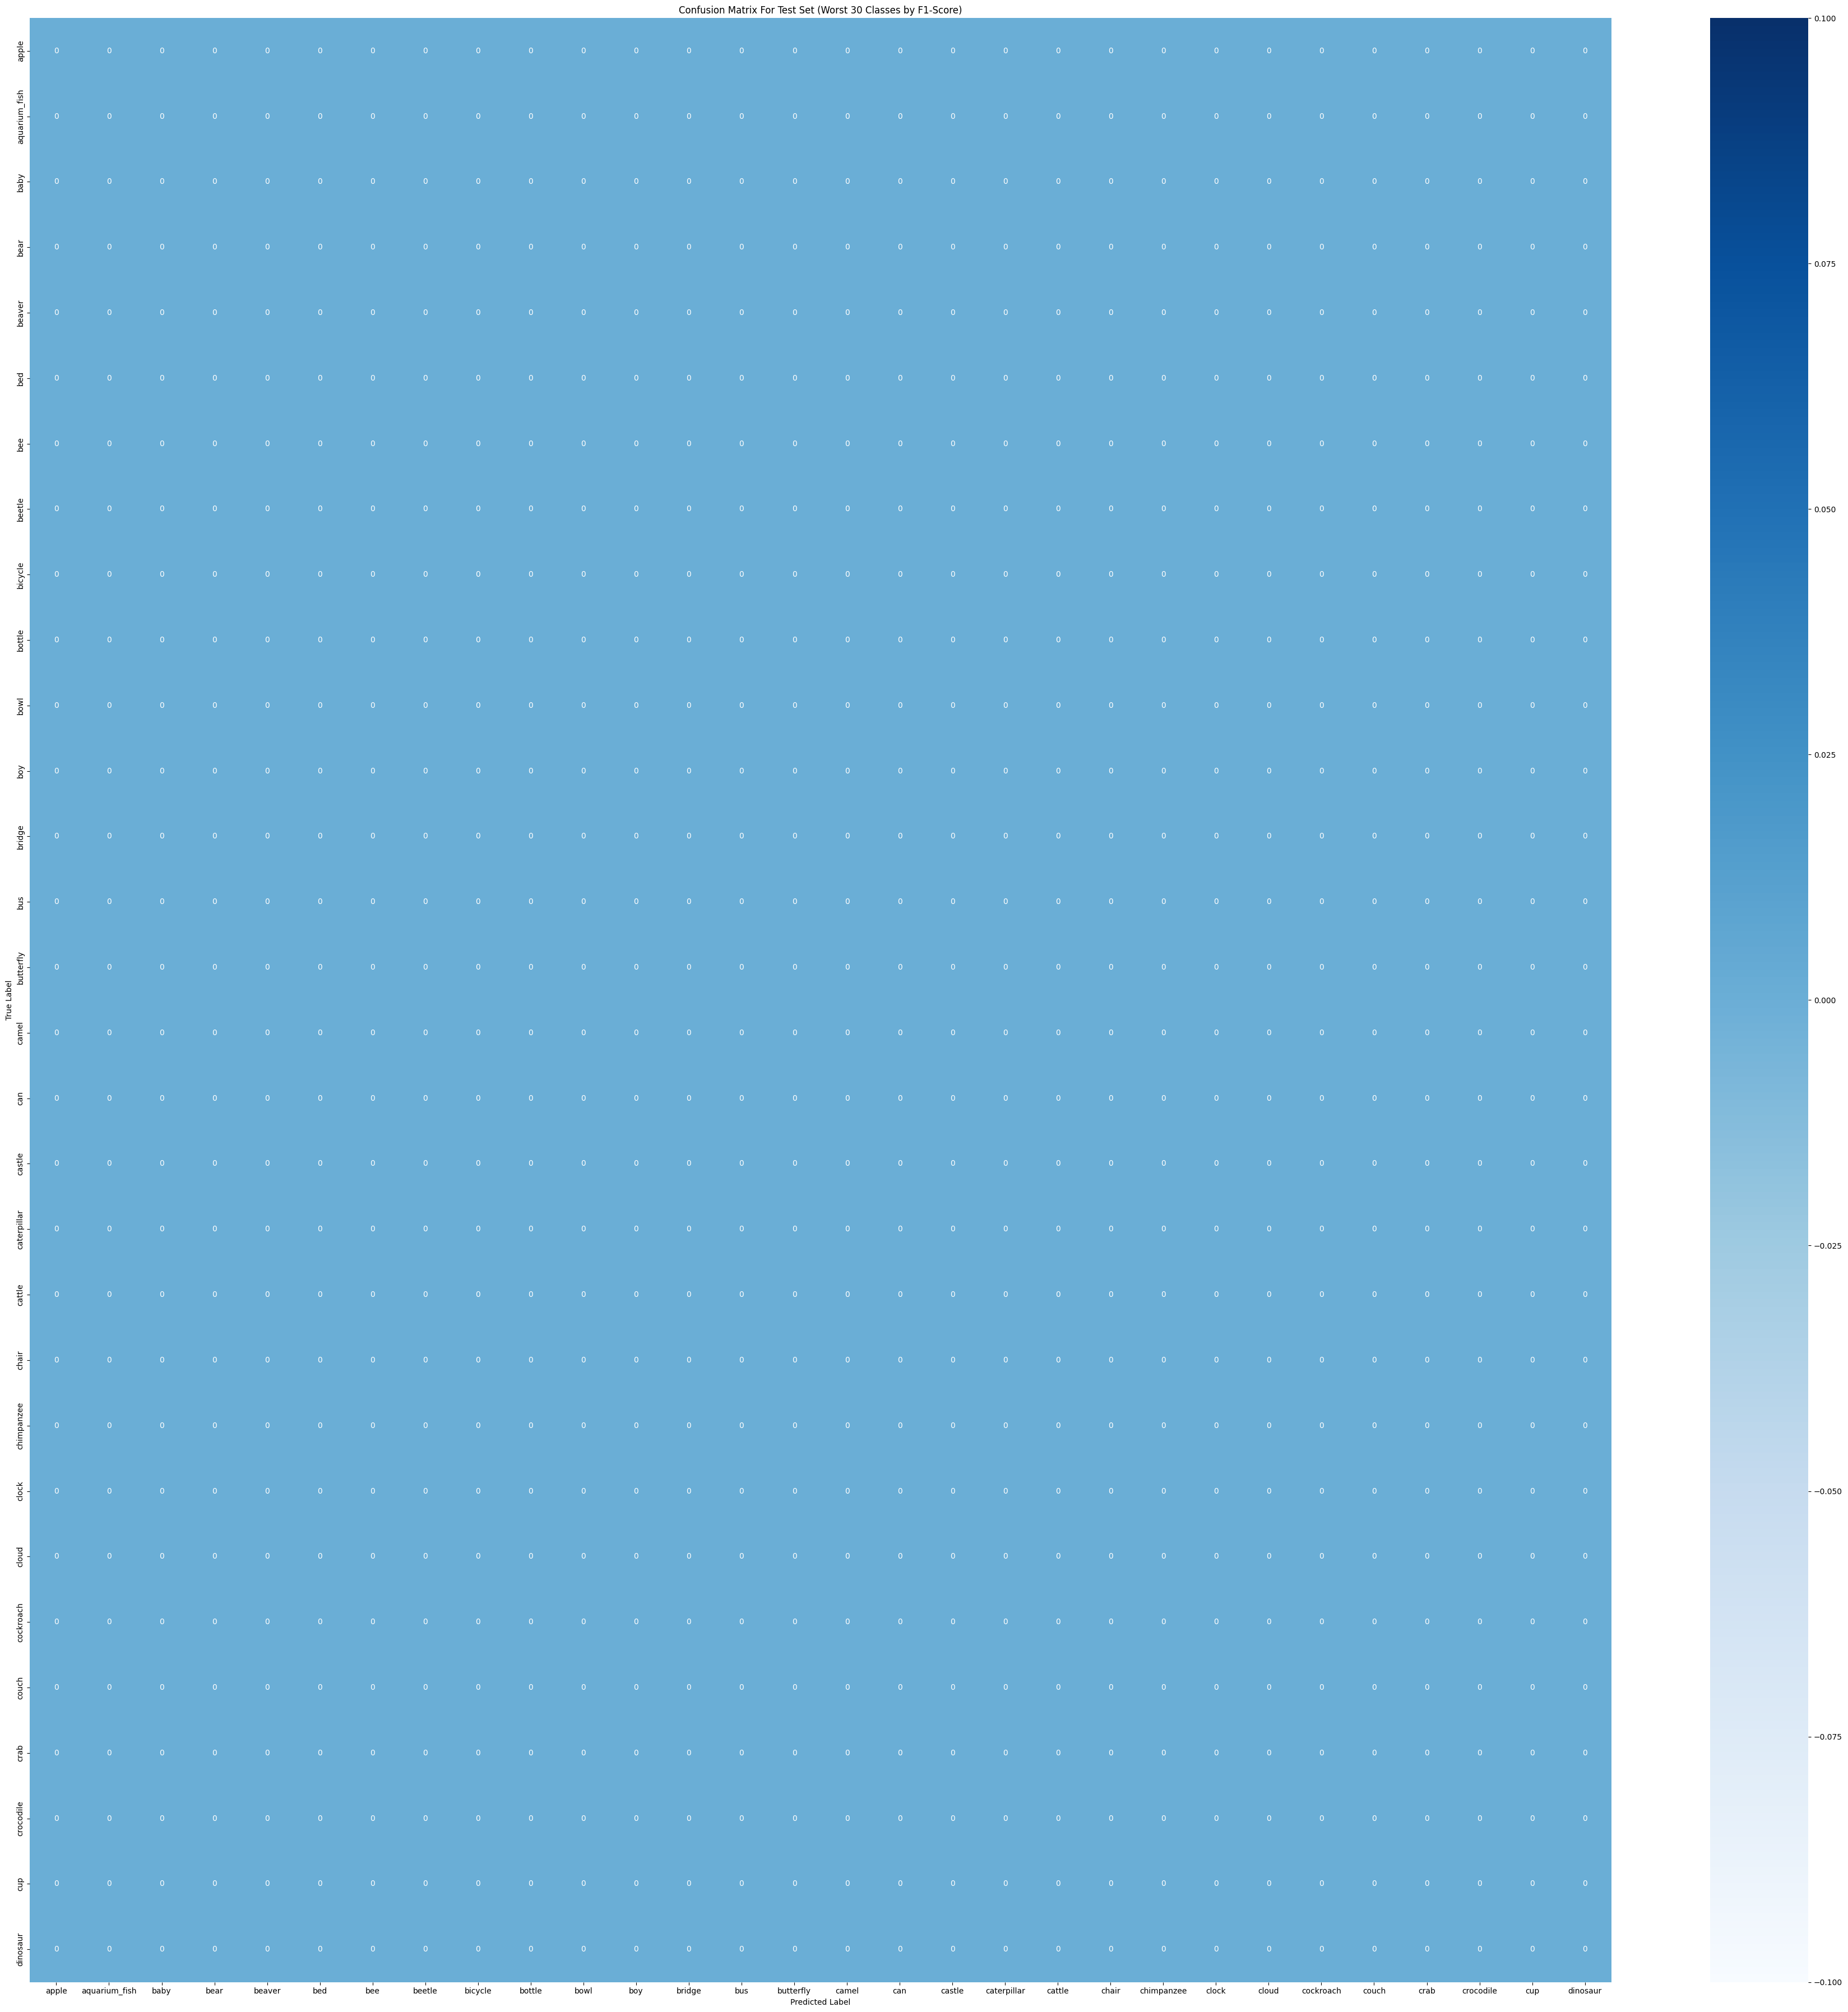

(array([49, 33, 72, ..., 51, 42, 70]),
 array([63, 63, 63, ..., 63, 63, 63]),
 array([[0.00671295, 0.00928211, 0.00863392, ..., 0.00538661, 0.0153051 ,
         0.01737795],
        [0.00678553, 0.00990956, 0.00889239, ..., 0.00536911, 0.01567023,
         0.01706282],
        [0.0064174 , 0.00947563, 0.00876533, ..., 0.00537106, 0.01641494,
         0.01625501],
        ...,
        [0.00658628, 0.0095477 , 0.0086764 , ..., 0.00554112, 0.01616228,
         0.01675499],
        [0.00687394, 0.00979185, 0.00881405, ..., 0.00547381, 0.0158512 ,
         0.01677   ],
        [0.00644565, 0.00974681, 0.00862723, ..., 0.0054863 , 0.01601619,
         0.01610011]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_mobilenet_35, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [ ]:
results['MobileNetV2_Unfreeze_35%'] = {
    'training_time': training_time_mobilenet_unfreeze_35,
    'val_accuracy': history_mobilenet_unfreeze_35.history['val_accuracy'][-1],
    'history': history_mobilenet_unfreeze_35
}

print(f"\MobileNetV2 Top 35% Unfreeze Training Time: {training_time_mobilenet_unfreeze_35:.2f} seconds")
print(f"MobileNetV2 Top 35% Unfreeze Validation Accuracy: {history_mobilenet_unfreeze_35.history['val_accuracy'][-1]:.4f}")

\MobileNetV2 Top 35% Unfreeze Training Time: 199.50 seconds
MobileNetV2 Top 35% Unfreeze Validation Accuracy: 0.0100


<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_4378/3275523719.py:7: SyntaxWarning: invalid escape sequence '\M'
  print(f"\MobileNetV2 Top 35% Unfreeze Training Time: {training_time_mobilenet_unfreeze_35:.2f} seconds")


### **Comparison of Fine-Tuning Strategies**

In [ ]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 414.39 seconds
  Validation Accuracy: 0.0117
  Effiency -> Accuracy / Seconds : 2.8234016106300675e-05
Model: MobileNetV2
  Training Time: 199.23 seconds
  Validation Accuracy: 0.0111
  Effiency -> Accuracy / Seconds : 5.571361899399804e-05
Model: MobileNetV2_Unfreeze_10%
  Training Time: 215.28 seconds
  Validation Accuracy: 0.0100
  Effiency -> Accuracy / Seconds : 4.645088873918798e-05
Model: MobileNetV2_Unfreeze_35%
  Training Time: 315.42 seconds
  Validation Accuracy: 0.0127
  Effiency -> Accuracy / Seconds : 4.026441133385011e-05

Best by Accuracy: MobileNetV2_Unfreeze_35% (0.0127)
Best by Time: MobileNetV2 (199.2331)
Efficient (accuracy/sec): MobileNetV2 (0.000056)


best is freezed mobilenet  
and second option is mobilenet with 10% unfreeze layers

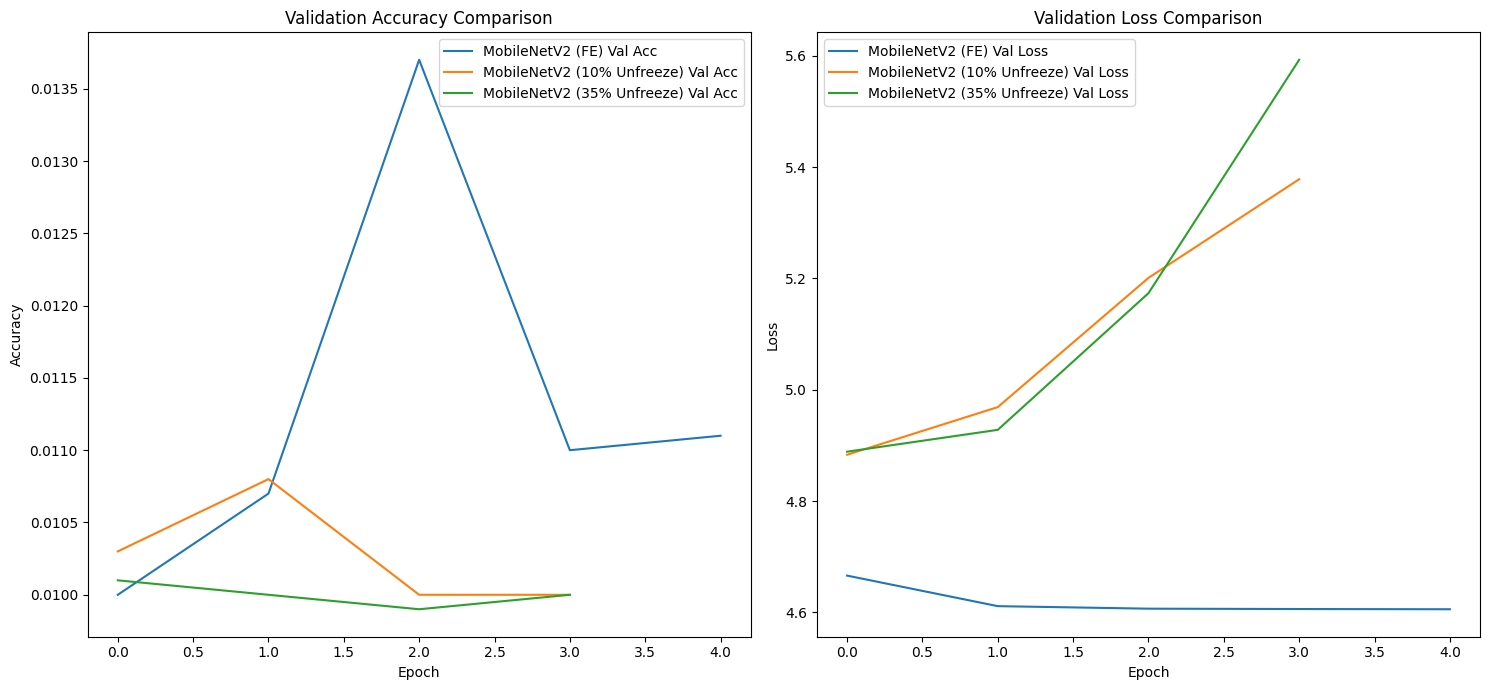

In [ ]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(results['MobileNetV2']['history'].history['val_accuracy'], label='MobileNetV2 (FE) Val Acc')
plt.plot(results['MobileNetV2_Unfreeze_10%']['history'].history['val_accuracy'], label='MobileNetV2 (10% Unfreeze) Val Acc')
plt.plot(results['MobileNetV2_Unfreeze_35%']['history'].history['val_accuracy'], label='MobileNetV2 (35% Unfreeze) Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['MobileNetV2']['history'].history['val_loss'], label='MobileNetV2 (FE) Val Loss')
plt.plot(results['MobileNetV2_Unfreeze_10%']['history'].history['val_loss'], label='MobileNetV2 (10% Unfreeze) Val Loss')
plt.plot(results['MobileNetV2_Unfreeze_35%']['history'].history['val_loss'], label='MobileNetV2 (35% Unfreeze) Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Try Fine-Tuning Also With ResNet50V2**

### **Top 10% Unfreezing**

In [ ]:
base_model_resnet_unfreeze_10 = keras.applications.ResNet50V2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
model_resnet_10 = build_model(base_model_resnet_unfreeze_10, data_augmentation, NUM_CLASSES)

In [ ]:
base_model_resnet_unfreeze_10.trainable = True

In [ ]:
total_layers_resnet = len(base_model_resnet.layers)
unfreeze_percentage_10 = 0.10
freeze_until_10 = int(total_layers_resnet * (1.0 - unfreeze_percentage_10))

for layer in base_model_resnet_unfreeze_10.layers[:freeze_until_10]:
    layer.trainable = False

In [ ]:
model_resnet_10.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 8,084,580 (30.84 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

In [ ]:
start_time_resnet_unfreeze_10 = time.time()
history_resnet_unfreeze_10 = train_model(model_resnet_10, "ResNet50V2_Unfreeze_10", train_dataset, test_dataset)
end_time_resnet_unfreeze_10 = time.time()
training_time_resnet_unfreeze_10 = end_time_resnet_unfreeze_10 - start_time_resnet_unfreeze_10

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.0280 - loss: 4.5264

782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 122ms/step - accuracy: 0.0414 - loss: 4.4240 - val_accuracy: 0.0796 - val_loss: 4.2060 - learning_rate: 9.5000e-06
Epoch 2/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.0743 - loss: 4.1886

782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.0828 - loss: 4.1371 - val_accuracy: 0.1169 - val_loss: 3.9685 - learning_rate: 9.0250e-06
Epoch 3/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1008 - loss: 4.0114

782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 123ms/step - accuracy: 0.1061 - loss: 3.9778 - val_accuracy: 0.1394 - val_loss: 3.8184 - learning_rate: 8.5737e-06
Epoch 4/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1175 - loss: 3.8922

782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 117ms/step - accuracy: 0.1225 - loss: 3.8626 - val_accuracy: 0.1587 - val_loss: 3.7254 - learning_rate: 8.1451e-06
Epoch 5/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1351 - loss: 3.7857

782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 117ms/step - accuracy: 0.1366 - loss: 3.7704 - val_accuracy: 0.1676 - val_loss: 3.6209 - learning_rate: 7.7378e-06


#### **Results**

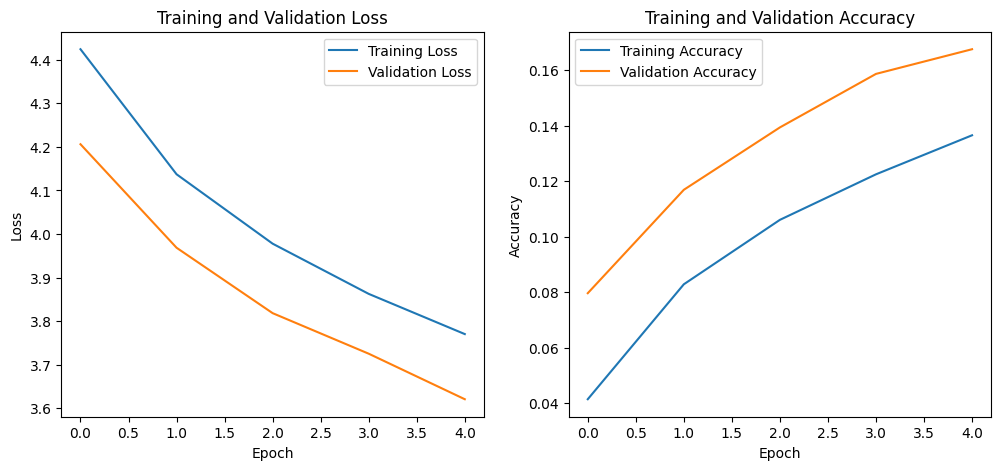

In [ ]:
plot_loss_accuracy_comparison(history_resnet_unfreeze_10)


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.36      0.36      0.36       100
aquarium_fish       0.14      0.36      0.20       100
         baby       0.06      0.03      0.04       100
         bear       0.00      0.00      0.00       100
       beaver       0.08      0.01      0.02       100
          bed       0.06      0.01      0.02       100
          bee       0.11      0.17      0.13       100
       beetle       0.26      0.14      0.18       100
      bicycle       0.21      0.21      0.21       100
       bottle       0.23      0.15      0.18       100
         bowl       0.07      0.03      0.04       100
          boy       0.00      0.00      0.00       100
       bridge       0.21      0.11      0.14       100
          bus       0.02      0.01      0.01       100
    butterfly       0.25      0.04      0.07       100
        camel       0.03      0.01      0.02       100
   

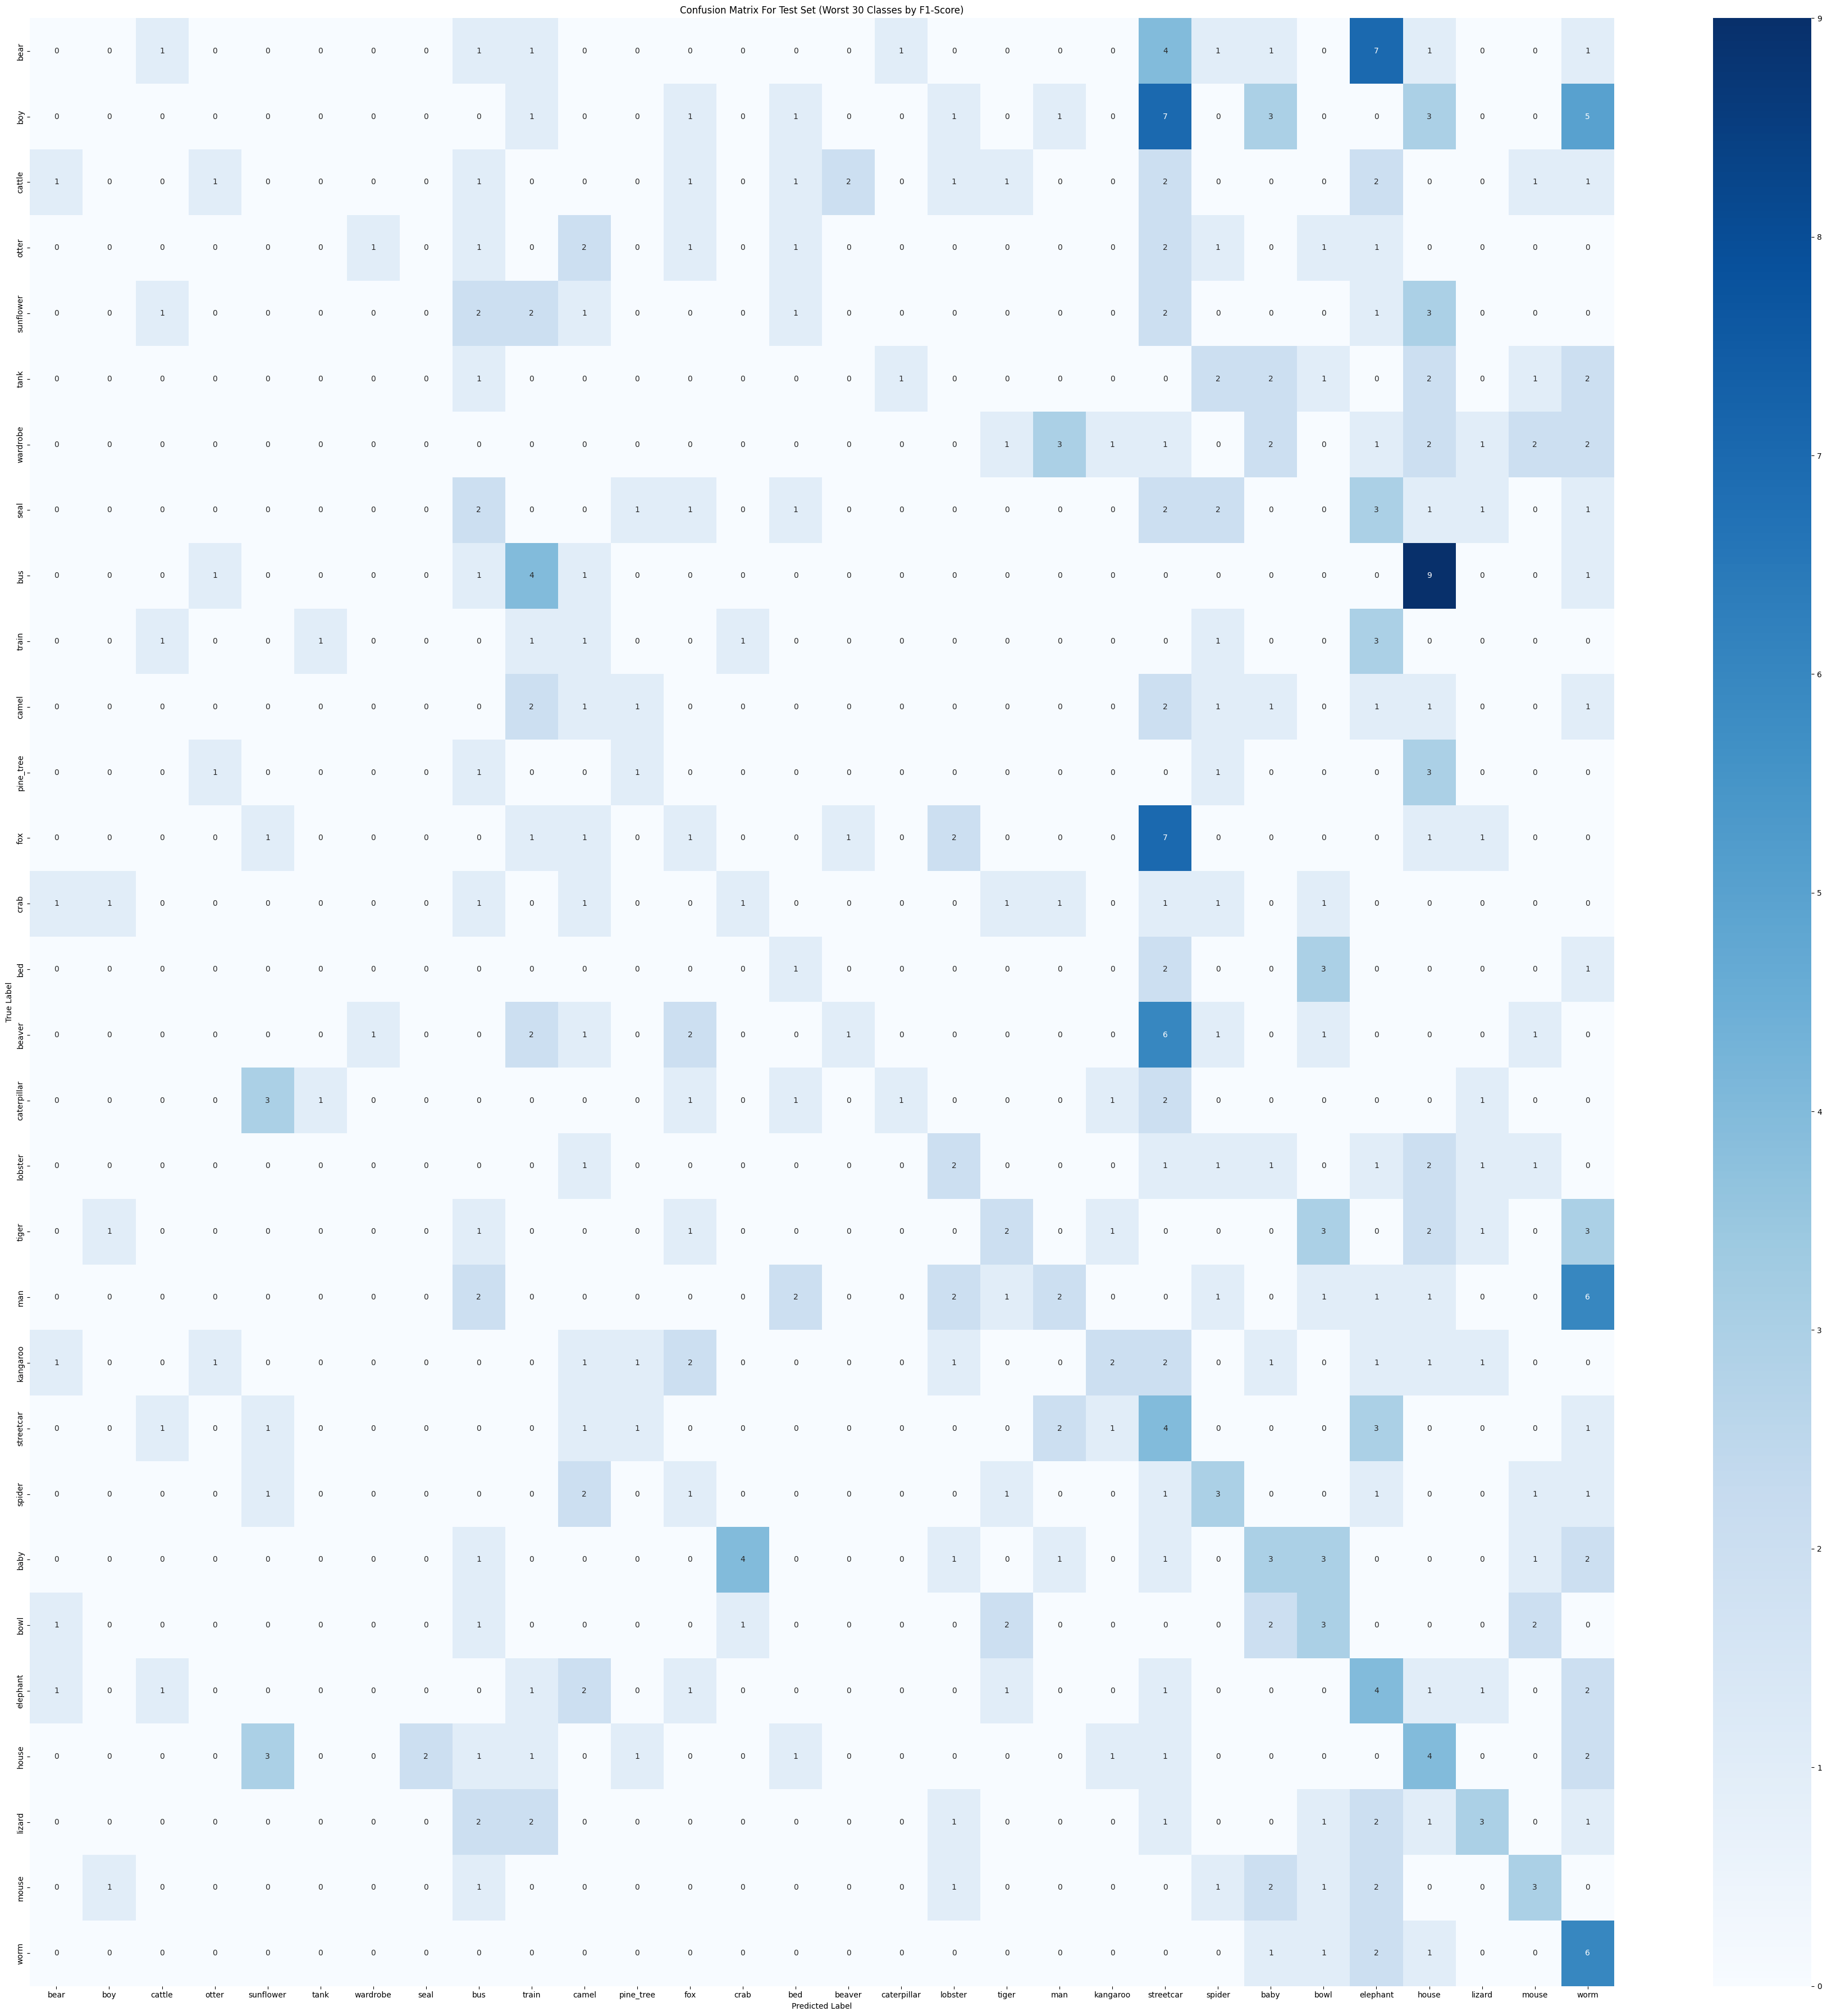

(array([49, 33, 72, ..., 51, 42, 70]),
 array([85, 63, 44, ..., 68, 88, 70]),
 array([[0.0008774 , 0.00098885, 0.00538133, ..., 0.00264861, 0.00470893,
         0.00963037],
        [0.00108804, 0.00719725, 0.00939372, ..., 0.00682211, 0.0045578 ,
         0.00525093],
        [0.00068467, 0.00565981, 0.00738281, ..., 0.01494766, 0.00385446,
         0.00446149],
        ...,
        [0.00120806, 0.00756947, 0.00452847, ..., 0.00345495, 0.00369866,
         0.01544391],
        [0.00148338, 0.0055684 , 0.01547559, ..., 0.01298133, 0.00704844,
         0.00538445],
        [0.00583021, 0.02866337, 0.02404713, ..., 0.00930057, 0.01669814,
         0.00275228]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_resnet_10, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [ ]:
results['ResNet50V2_Unfreeze_10%'] = {
    'training_time': training_time_resnet_unfreeze_10,
    'val_accuracy': history_resnet_unfreeze_10.history['val_accuracy'][-1],
    'history': history_resnet_unfreeze_10
}

print(f"\ResNet50V2 Top 10% Unfreeze Training Time: {training_time_resnet_unfreeze_10:.2f} seconds")
print(f"ResNet50V2 Top 10% Unfreeze Validation Accuracy: {history_resnet_unfreeze_10.history['val_accuracy'][-1]:.4f}")

\ResNet50V2 Top 10% Unfreeze Training Time: 576.31 seconds
ResNet50V2 Top 10% Unfreeze Validation Accuracy: 0.1676


<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_4378/521037464.py:7: SyntaxWarning: invalid escape sequence '\R'
  print(f"\ResNet50V2 Top 10% Unfreeze Training Time: {training_time_resnet_unfreeze_10:.2f} seconds")


### **Deep 35% Unfreezing**

In [ ]:
base_model_resnet_unfreeze_35 = keras.applications.ResNet50V2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
model_resnet_35 = build_model(base_model_resnet_unfreeze_35, data_augmentation, NUM_CLASSES)

In [ ]:
base_model_resnet_unfreeze_35.trainable = True

In [ ]:
total_layers_res_net = len(base_model_resnet.layers)
unfreeze_percentage_35 = 0.10
freeze_until_35 = int(total_layers_res_net * (1.0 - unfreeze_percentage_35))

for layer in base_model_resnet_unfreeze_35.layers[:freeze_until_35]:
    layer.trainable = False

In [ ]:
model_resnet_35.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 8,084,580 (30.84 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

In [ ]:
start_time_resnet_unfreeze_35 = time.time()
history_resnet_unfreeze_35 = train_model(model_resnet_35, "ResNet50V2_Unfreeze_35", train_dataset, test_dataset)
end_time_resnet_unfreeze_35 = time.time()
training_time_resnet_unfreeze_35 = end_time_resnet_unfreeze_35 - start_time_resnet_unfreeze_35

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.0297 - loss: 4.5179

782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 127ms/step - accuracy: 0.0455 - loss: 4.4076 - val_accuracy: 0.0850 - val_loss: 4.1725 - learning_rate: 9.5000e-06
Epoch 2/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0787 - loss: 4.1782

782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.0844 - loss: 4.1307 - val_accuracy: 0.1169 - val_loss: 3.9564 - learning_rate: 9.0250e-06
Epoch 3/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1030 - loss: 4.0086

782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.1065 - loss: 3.9771 - val_accuracy: 0.1386 - val_loss: 3.8228 - learning_rate: 8.5737e-06
Epoch 4/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1195 - loss: 3.8846

782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.1234 - loss: 3.8601 - val_accuracy: 0.1517 - val_loss: 3.7131 - learning_rate: 8.1451e-06
Epoch 5/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1333 - loss: 3.7993

782/782 ━━━━━━━━━━━━━━━━━━━━ 105s 135ms/step - accuracy: 0.1362 - loss: 3.7779 - val_accuracy: 0.1623 - val_loss: 3.6527 - learning_rate: 7.7378e-06


#### **Results**

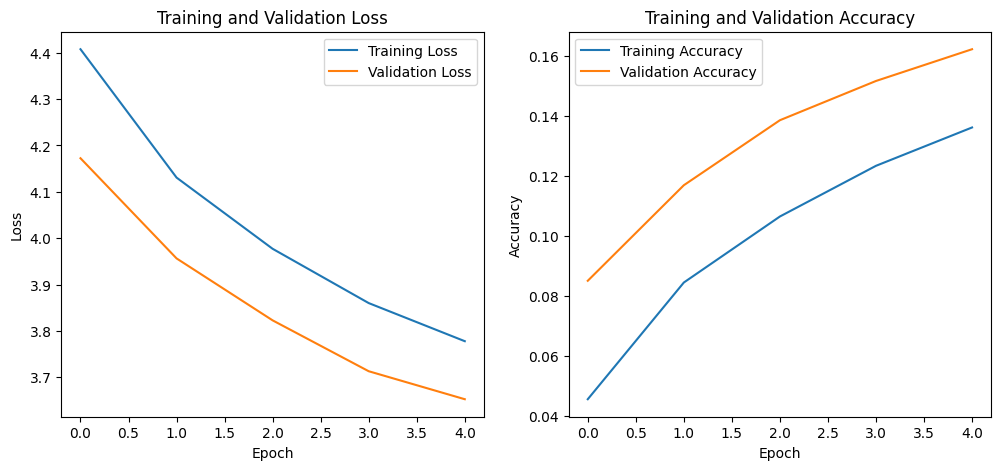

In [ ]:
plot_loss_accuracy_comparison(history_resnet_unfreeze_35)


Confusion Matrix For Test Set
-----------------------------
               precision    recall  f1-score   support

        apple       0.37      0.37      0.37       100
aquarium_fish       0.17      0.33      0.22       100
         baby       0.06      0.03      0.04       100
         bear       0.06      0.04      0.05       100
       beaver       0.17      0.01      0.02       100
          bed       0.22      0.02      0.04       100
          bee       0.10      0.22      0.13       100
       beetle       0.21      0.14      0.17       100
      bicycle       0.19      0.22      0.20       100
       bottle       0.42      0.11      0.17       100
         bowl       0.11      0.08      0.09       100
          boy       0.00      0.00      0.00       100
       bridge       0.16      0.10      0.12       100
          bus       0.04      0.02      0.03       100
    butterfly       0.23      0.03      0.05       100
        camel       0.09      0.01      0.02       100
   

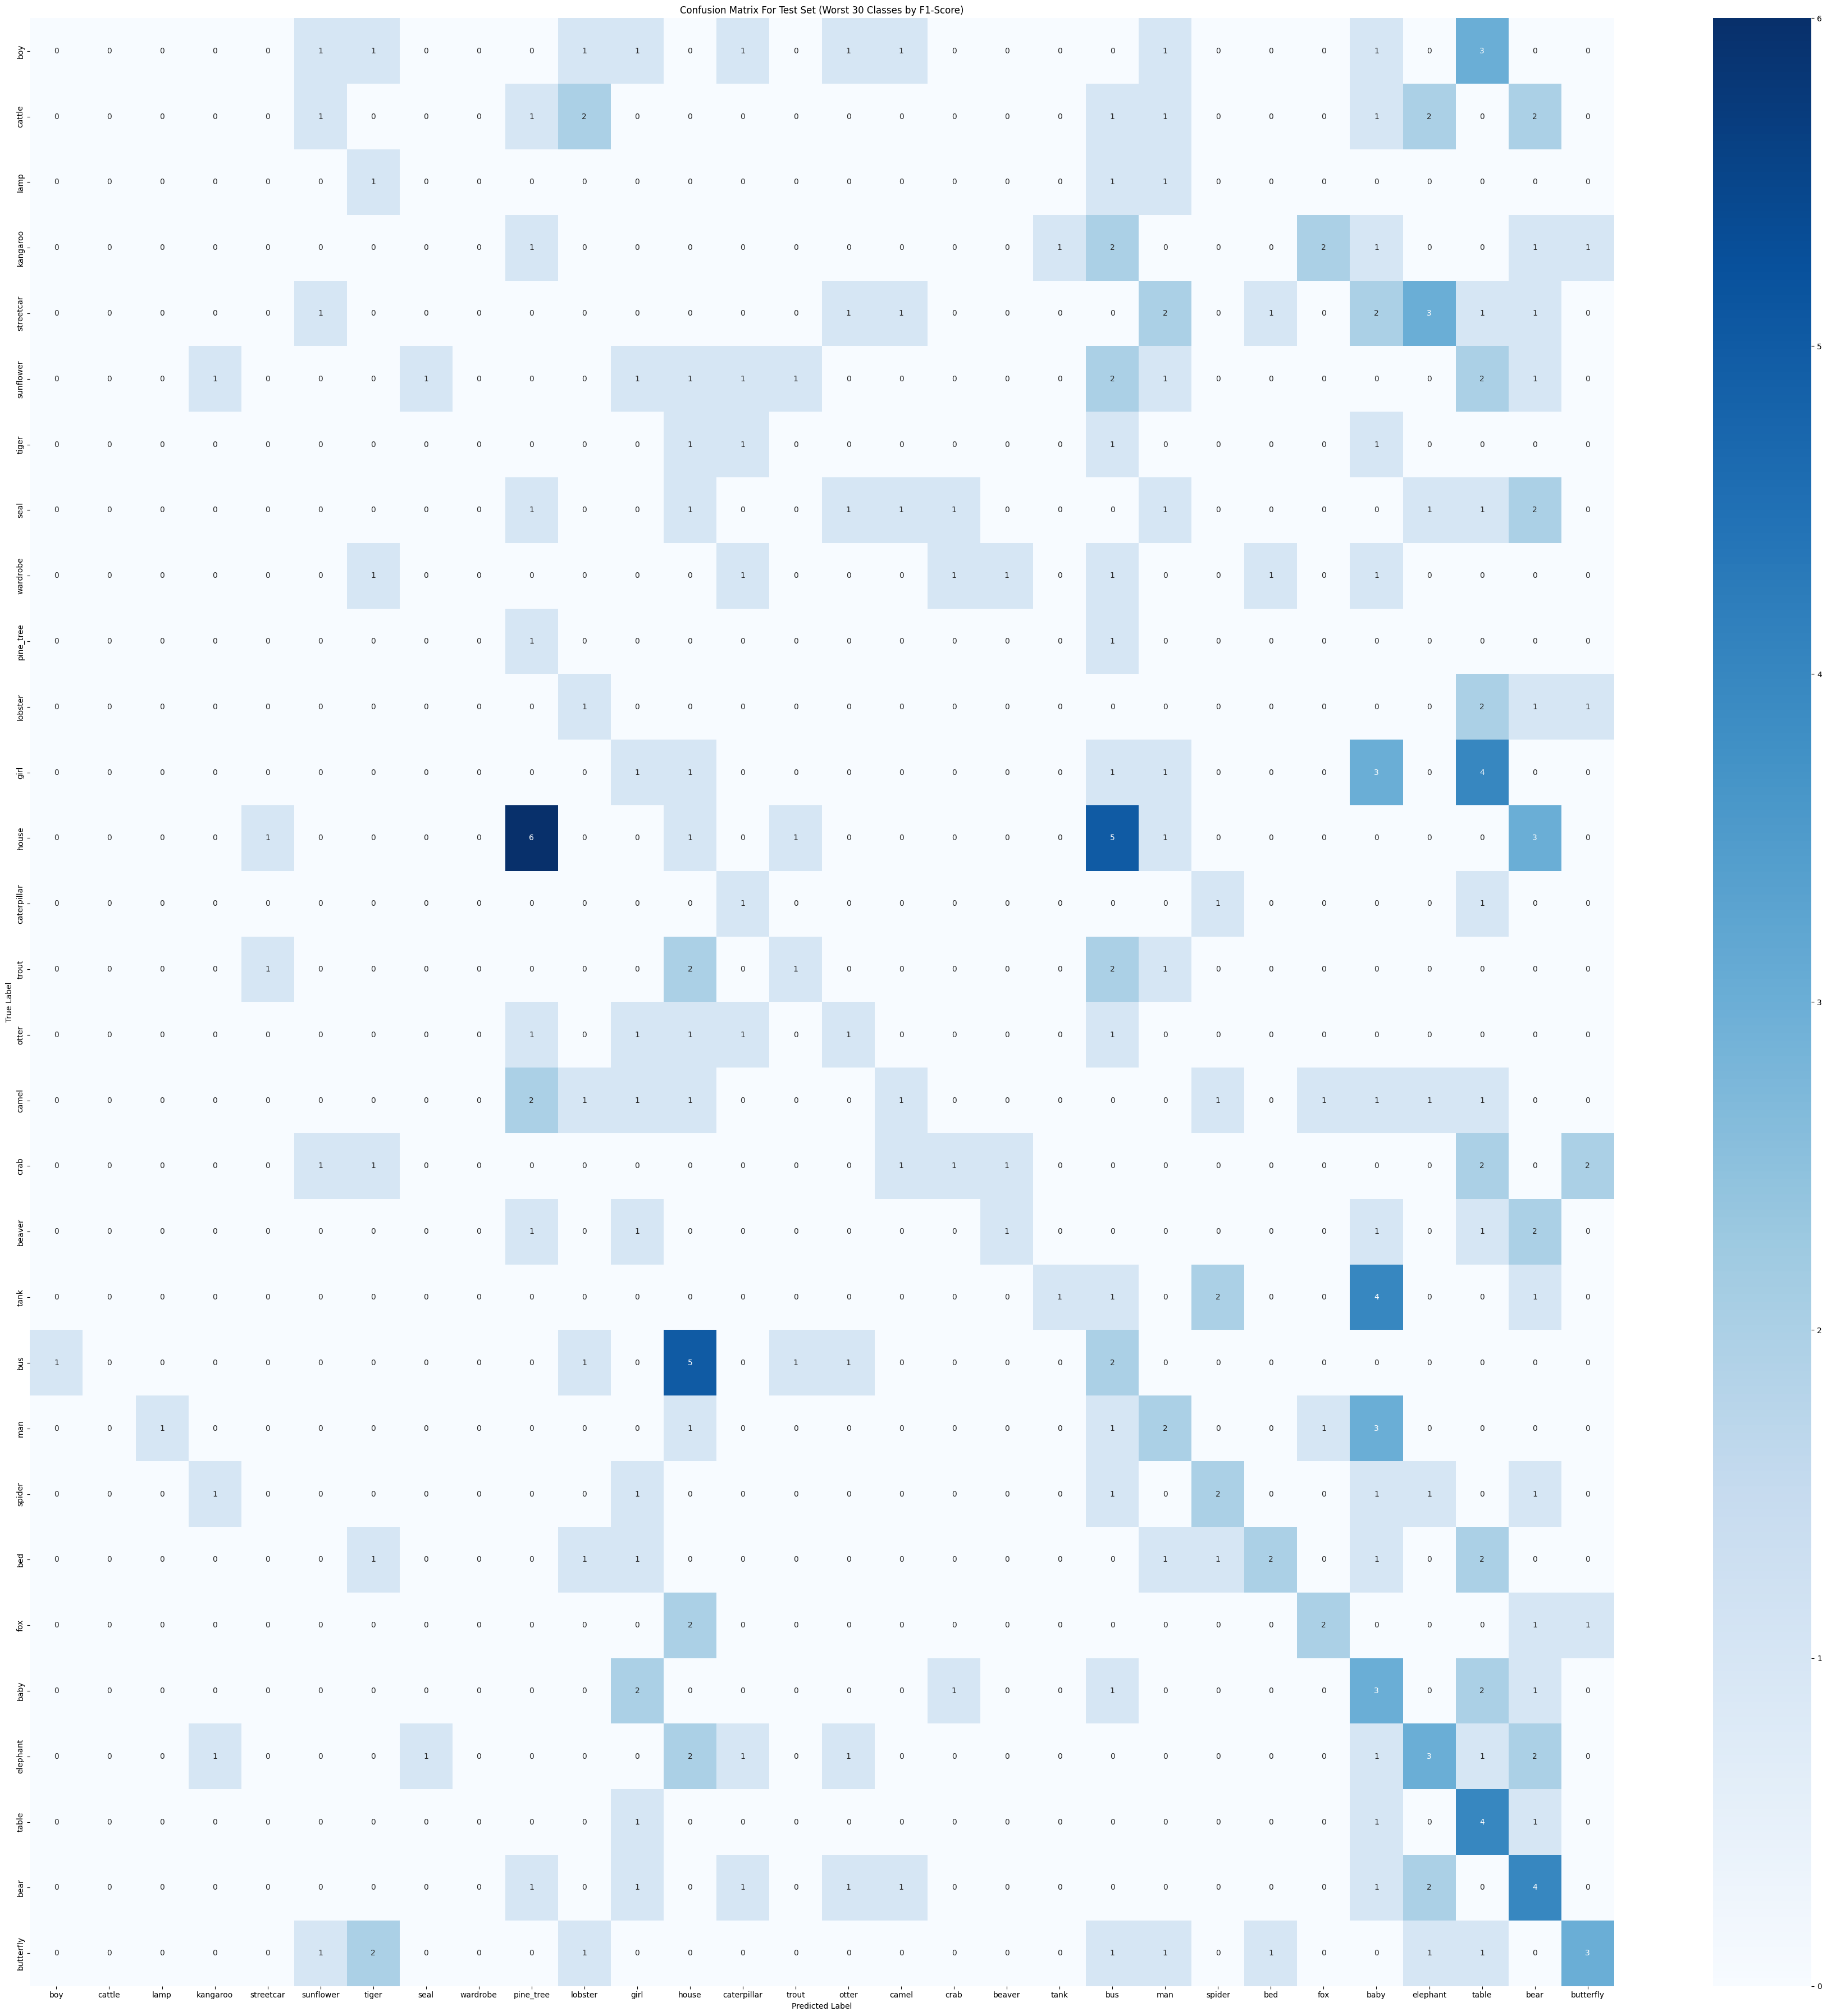

(array([49, 33, 72, ..., 51, 42, 70]),
 array([85, 63,  6, ..., 68, 88, 70]),
 array([[0.00029911, 0.00032009, 0.00308712, ..., 0.00167646, 0.00354669,
         0.00423712],
        [0.00349768, 0.01003817, 0.00854867, ..., 0.00849025, 0.00639301,
         0.01071856],
        [0.00125997, 0.00611361, 0.0101367 , ..., 0.02484635, 0.01155885,
         0.0039438 ],
        ...,
        [0.00167807, 0.00822082, 0.00288542, ..., 0.00856695, 0.00417236,
         0.02509648],
        [0.00081167, 0.00410356, 0.00850764, ..., 0.01959902, 0.00819235,
         0.00898434],
        [0.00499511, 0.01668138, 0.01311048, ..., 0.01183871, 0.01384665,
         0.00197463]], dtype=float32))

In [ ]:
confunsion_matrix_and_classfication_report(model_resnet_35, test_dataset, title="Confusion Matrix For Test Set", class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [ ]:
results['ResNet50V2_Unfreeze_35%'] = {
    'training_time': training_time_resnet_unfreeze_35,
    'val_accuracy': history_resnet_unfreeze_35.history['val_accuracy'][-1],
    'history': history_resnet_unfreeze_35
}

print(f"\ResNet50V2 Top 35% Unfreeze Training Time: {training_time_resnet_unfreeze_35:.2f} seconds")
print(f"ResNet50V2 Top 35% Unfreeze Validation Accuracy: {history_resnet_unfreeze_35.history['val_accuracy'][-1]:.4f}")

\ResNet50V2 Top 35% Unfreeze Training Time: 498.86 seconds
ResNet50V2 Top 35% Unfreeze Validation Accuracy: 0.1623


<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_4378/1894833990.py:7: SyntaxWarning: invalid escape sequence '\R'
  print(f"\ResNet50V2 Top 35% Unfreeze Training Time: {training_time_resnet_unfreeze_35:.2f} seconds")


### **Comparison of Fine-Tuning Strategies**

In [ ]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 414.39 seconds
  Validation Accuracy: 0.0117
  Effiency -> Accuracy / Seconds : 2.8234016106300675e-05
Model: MobileNetV2
  Training Time: 199.23 seconds
  Validation Accuracy: 0.0111
  Effiency -> Accuracy / Seconds : 5.571361899399804e-05
Model: MobileNetV2_Unfreeze_10%
  Training Time: 215.28 seconds
  Validation Accuracy: 0.0100
  Effiency -> Accuracy / Seconds : 4.645088873918798e-05
Model: MobileNetV2_Unfreeze_35%
  Training Time: 199.50 seconds
  Validation Accuracy: 0.0100
  Effiency -> Accuracy / Seconds : 5.012645287670967e-05
Model: ResNet50V2_Unfreeze_10%
  Training Time: 576.31 seconds
  Validation Accuracy: 0.1676
  Effiency -> Accuracy / Seconds : 0.000290813429834428
Model: ResNet50V2_Unfreeze_35%
  Training Time: 498.86 seconds
  Validation Accuracy: 0.1623
  Effiency -> Accuracy / Seconds : 0.00032534306097106253

Best by Accuracy: ResNet50V2_Unfreeze_10% (0.1676)
Best by Time: MobileNetV2 (199.2331)
Efficient (accuracy/sec): ResNet5

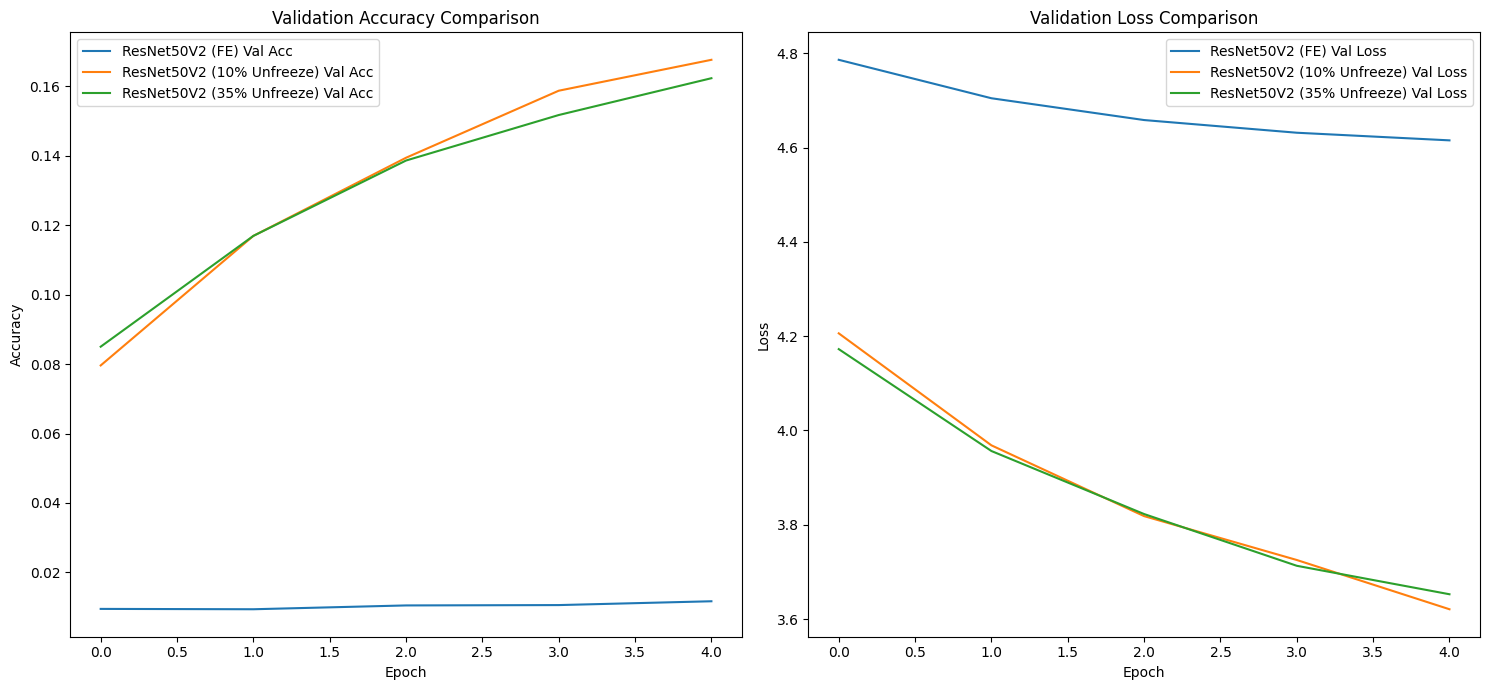

In [ ]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(results['ResNet50V2']['history'].history['val_accuracy'], label='ResNet50V2 (FE) Val Acc')
plt.plot(results['ResNet50V2_Unfreeze_10%']['history'].history['val_accuracy'], label='ResNet50V2 (10% Unfreeze) Val Acc')
plt.plot(results['ResNet50V2_Unfreeze_35%']['history'].history['val_accuracy'], label='ResNet50V2 (35% Unfreeze) Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['ResNet50V2']['history'].history['val_loss'], label='ResNet50V2 (FE) Val Loss')
plt.plot(results['ResNet50V2_Unfreeze_10%']['history'].history['val_loss'], label='ResNet50V2 (10% Unfreeze) Val Loss')
plt.plot(results['ResNet50V2_Unfreeze_35%']['history'].history['val_loss'], label='ResNet50V2 (35% Unfreeze) Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **An Obvious Problem**

ok even after using pretrained model like resnet & fine-tune & augmentation , the results is really bad.

the reason : maybe
- the number of epochs is really low
- the models are not that suitable for the data
- need to make a heavier augmentation cause each class has a really small number of pictures

so I will try....

and we already have x_train, x_test, y_train, y_test

let us first try a manual architecture for resnet but i think it will work better

In [ ]:
def train_model_improved(model, text, x_train, y_train, x_test, y_test,
                         BATCH_SIZE, optimizer_type, new_loss, patience = 10,
                         learning_rate = 1e-5, EPOCHS = 5):

    optimizers_map = {
        'adam': tf.keras.optimizers.Adam(learning_rate=learning_rate),
        'sgd': tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True),
        'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
    }

    if isinstance(optimizer_type, str):
        optimizer = optimizers_map.get(optimizer_type.lower())
    else:
        optimizer = optimizer_type

    model.compile(
        optimizer = optimizer,
        loss = new_loss,
        metrics = ['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = patience, restore_best_weights = True),
        tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.95),
        tf.keras.callbacks.ModelCheckpoint(f"{text} best_model.h5", save_best_only = True, monitor = 'val_loss', mode = 'min')
    ]

    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    training_time = time.time() - start_time

    print(f"\n{model_name} — Training completed in {training_time:.2f} seconds")

    return history

## **CNN Architecture**

- Built for 32×32 input (not resized to 224×224) : Avoids wasting compute upsampling blurry pixels — trains faster and often generalizes better on CIFAR-scale data
- ~11M parameters	: Small enough that a T4 handles batch_size=128 comfortably without running out of memory
- Residual connections : (4 stages) to learn fine-grained distinctions between 100 classes, without vanishing-gradient issues a plain CNN would hit at this depth
- SGD + momentum + cosine decay : The standard recipe from CIFAR benchmark papers — tends to outperform Adam on this specific task at convergence, though slower to get started
- Label smoothing (0.1) :	Helps a lot with 100 classes since some are visually similar (e.g. maple vs oak)
- Built-in augmentation layers : Runs on GPU as part of the model graph — faster than CPU-side augmentation pipelines

In [ ]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


In [ ]:
def build_cifar100_resnet(input_shape=(32, 32, 3), num_classes=100):
    inputs = layers.Input(shape=input_shape)

    # Data augmentation baked into the model (only active during training)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomTranslation(0.1, 0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Stem
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1 — 32x32
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # Stage 2 — 16x16
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Stage 3 — 8x8
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Stage 4 — 4x4
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="mini_resnet_cifar100")
    return model


cnn_model = build_cifar100_resnet()
cnn_model.summary()

Model: "mini_resnet_cifar100"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_51      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_4       │ (None, 32, 32, 3) │          0 │ input_layer_51[0… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 32, 32, 3) │          0 │ random_flip_4[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_4       │ (None, 32, 32, 3) │          0 │ random_translati… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │      1,728 │ random_zoom_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │     36,864 │ re_lu_17[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     36,864 │ re_lu_18[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 32, 32,    │          0 │ add_8[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     36,864 │ re_lu_19[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 11,229,732 (42.84 MB)

 Trainable params: 11,220,132 (42.80 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
EPOCHS = 60
BATCH_SIZE = 128
learning_rate = 1e-5

steps_per_epoch = len(x_train) // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=steps_per_epoch * EPOCHS
)

loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

In [ ]:
history_cnn = train_model_improved(cnn_model, "cnn_model", x_train, y_train, x_test, y_test,
                               BATCH_SIZE, 'adam', loss, patience = 10,
                               learning_rate = 1e-5, EPOCHS = EPOCHS)

Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.0214 - loss: 5.1075

391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 181ms/step - accuracy: 0.0310 - loss: 4.8312 - val_accuracy: 0.0249 - val_loss: 4.5724 - learning_rate: 9.5000e-06
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.0586 - loss: 4.4190

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.0659 - loss: 4.3544 - val_accuracy: 0.1292 - val_loss: 4.0158 - learning_rate: 9.0250e-06
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.0864 - loss: 4.1904

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.0895 - loss: 4.1754 - val_accuracy: 0.1421 - val_loss: 3.9023 - learning_rate: 8.5737e-06
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1017 - loss: 4.0812

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.1051 - loss: 4.0626 - val_accuracy: 0.1589 - val_loss: 3.8204 - learning_rate: 8.1451e-06
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.1186 - loss: 3.9872

...

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.2596 - loss: 3.3293 - val_accuracy: 0.2885 - val_loss: 3.2184 - learning_rate: 2.6352e-06
Epoch 27/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2655 - loss: 3.3133

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 175ms/step - accuracy: 0.2631 - loss: 3.3225 - val_accuracy: 0.2892 - val_loss: 3.2023 - learning_rate: 2.5034e-06
Epoch 28/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2685 - loss: 3.2973

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.2667 - loss: 3.3071 - val_accuracy: 0.2906 - val_loss: 3.2015 - learning_rate: 2.3783e-06
Epoch 29/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2673 - loss: 3.3016

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 175ms/step - accuracy: 0.2681 - loss: 3.2997 - val_accuracy: 0.2939 - val_loss: 3.1918 - learning_rate: 2.2594e-06
Epoch 30/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2667 - loss: 3.2968

391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 175ms/step - accuracy: 0.2683 - loss: 3.2926 - val_accuracy: 0.2950 - val_loss: 3.1839 - learning_rate: 2.1464e-06
Epoch 31/60
358/391 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.2731 - loss: 3.2856